# Topic Comparison — Joint UMAP & Density Analysis
Comparative visualisations of the papers and iGEM-teams topic models projected into a shared embedding space.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from itertools import cycle
from umap import UMAP

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)

ASSETS = os.path.join('..', 'assets')
MODELS = os.path.join(ASSETS, 'topic_models')
EMBEDS = os.path.join(ASSETS, 'embeddings')
REPORTS = os.path.join(ASSETS, 'reports')

In [2]:
# Load papers dataset (only columns needed downstream)
papers = pd.read_csv(os.path.join(ASSETS, 'synbio_openalex.txt'), sep='\t')
papers['cited_by_count'] = pd.to_numeric(papers['cited_by_count'], errors='coerce').fillna(0).astype(int)
papers['publication_year'] = pd.to_numeric(papers['publication_year'], errors='coerce')

# Load papers topic assignments and names (used by UMAP plotting helpers)
doc_topics = pd.read_csv(os.path.join(MODELS, 'papers_doc_topics.txt'), sep='\t')
topic_names = pd.read_csv(os.path.join(MODELS, 'papers_topic_names.txt'), sep='\t')

print(f"Papers: {len(papers):,}")
print(f"Topics: {doc_topics['topic'].nunique()} (incl. outlier -1)")

Papers: 24,202
Topics: 264 (incl. outlier -1)


## Topic model plots — Joint UMAP space

Both papers and teams embeddings come from the same `all-MiniLM-L6-v2` encoder (384-dim), so we project **all documents together** into a single 2D UMAP manifold. This ensures proximity between a paper and a team project is directly interpretable — no post-hoc alignment needed.

In [3]:
# Load embeddings for both corpora
papers_emb = np.load(os.path.join(EMBEDS, 'papers_embeddings.npy'))
teams_emb  = np.load(os.path.join(EMBEDS, 'teams_embeddings.npy'))

# Load teams topic assignments and names
teams_doc_topics  = pd.read_csv(os.path.join(MODELS, 'teams_doc_topics.txt'), sep='\t')
teams_topic_names = pd.read_csv(os.path.join(MODELS, 'teams_topic_names.txt'), sep='\t')

n_papers = len(papers_emb)
n_teams  = len(teams_emb)
print(f"Papers embeddings: {papers_emb.shape}")
print(f"Teams embeddings:  {teams_emb.shape}")
assert n_papers == len(doc_topics), "Papers embeddings vs doc_topics mismatch"
assert n_teams  == len(teams_doc_topics), "Teams embeddings vs doc_topics mismatch"

Papers embeddings: (24202, 384)
Teams embeddings:  (4548, 384)


In [4]:
# Joint 2D UMAP: stack papers + teams, project together
all_emb = np.vstack([papers_emb, teams_emb])

umap_2d = UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=SEED,
)
all_xy = umap_2d.fit_transform(all_emb)

papers_xy = all_xy[:n_papers]
teams_xy  = all_xy[n_papers:]
print(f"Joint projection: {all_xy.shape}  (papers {papers_xy.shape}, teams {teams_xy.shape})")

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Joint projection: (28750, 2)  (papers (24202, 2), teams (4548, 2))


In [24]:
# Color palette (recycled)
palette = [
    "#f00f15", "#2270e7", "#e5e510", "#ff8103", "#4f3dd1",
    "#26cc3a", "#ec058e", "#9cb8c2", "#fffdd0", "#b40e68",
    "#5afb5a", "#beaed4", "#fdc086", "#99fdff", "#c430ff",
    "#e4dbe0", "#bf5b17", "#666666",
]

def build_plot_df(xy, dt, tn, id_col='id', size_col=None, size_df=None):
    """Build a plotting dataframe with x, y, topic, color, global_name."""
    df = dt.copy()
    df['x'] = xy[:, 0]
    df['y'] = xy[:, 1]
    df = df.merge(tn[['topic', 'global_name']], on='topic', how='left')
    if size_col and size_df is not None:
        df = df.merge(
            size_df[[id_col, size_col]].drop_duplicates(id_col),
            on=id_col, how='left',
        )
    # Assign colors
    topics_sorted = sorted(df.loc[df['topic'] >= 0, 'topic'].unique())
    cc = cycle(palette)
    cmap = {t: next(cc) for t in topics_sorted}
    cmap[-1] = '#d3d3d3'
    df['color'] = df['topic'].map(cmap)
    return df, topics_sorted

# Papers plotting dataframe
df_papers, papers_topics = build_plot_df(
    papers_xy, doc_topics, topic_names,
    id_col='id', size_col='cited_by_count', size_df=papers,
)

# Teams plotting dataframe
df_teams, teams_topics = build_plot_df(
    teams_xy, teams_doc_topics, teams_topic_names,
    id_col='UT',
)

# Shared axis limits from the joint UMAP projection (consistent across all plots)
_pad = 1.5
XLIM = (all_xy[:, 0].min() - _pad, all_xy[:, 0].max() + _pad)
YLIM = (all_xy[:, 1].min() - _pad, all_xy[:, 1].max() + _pad)

print(f"Papers: {len(df_papers):,} pts, {len(papers_topics)} topics")
print(f"Teams:  {len(df_teams):,} pts, {len(teams_topics)} topics")
print(f"Shared axis limits: x={XLIM}, y={YLIM}")

Papers: 24,202 pts, 263 topics
Teams:  4,548 pts, 161 topics
Shared axis limits: x=(np.float32(-6.5288377), np.float32(19.218245)), y=(np.float32(-2.0912228), np.float32(16.082216))


Saved → ../assets/reports/umap_papers.png


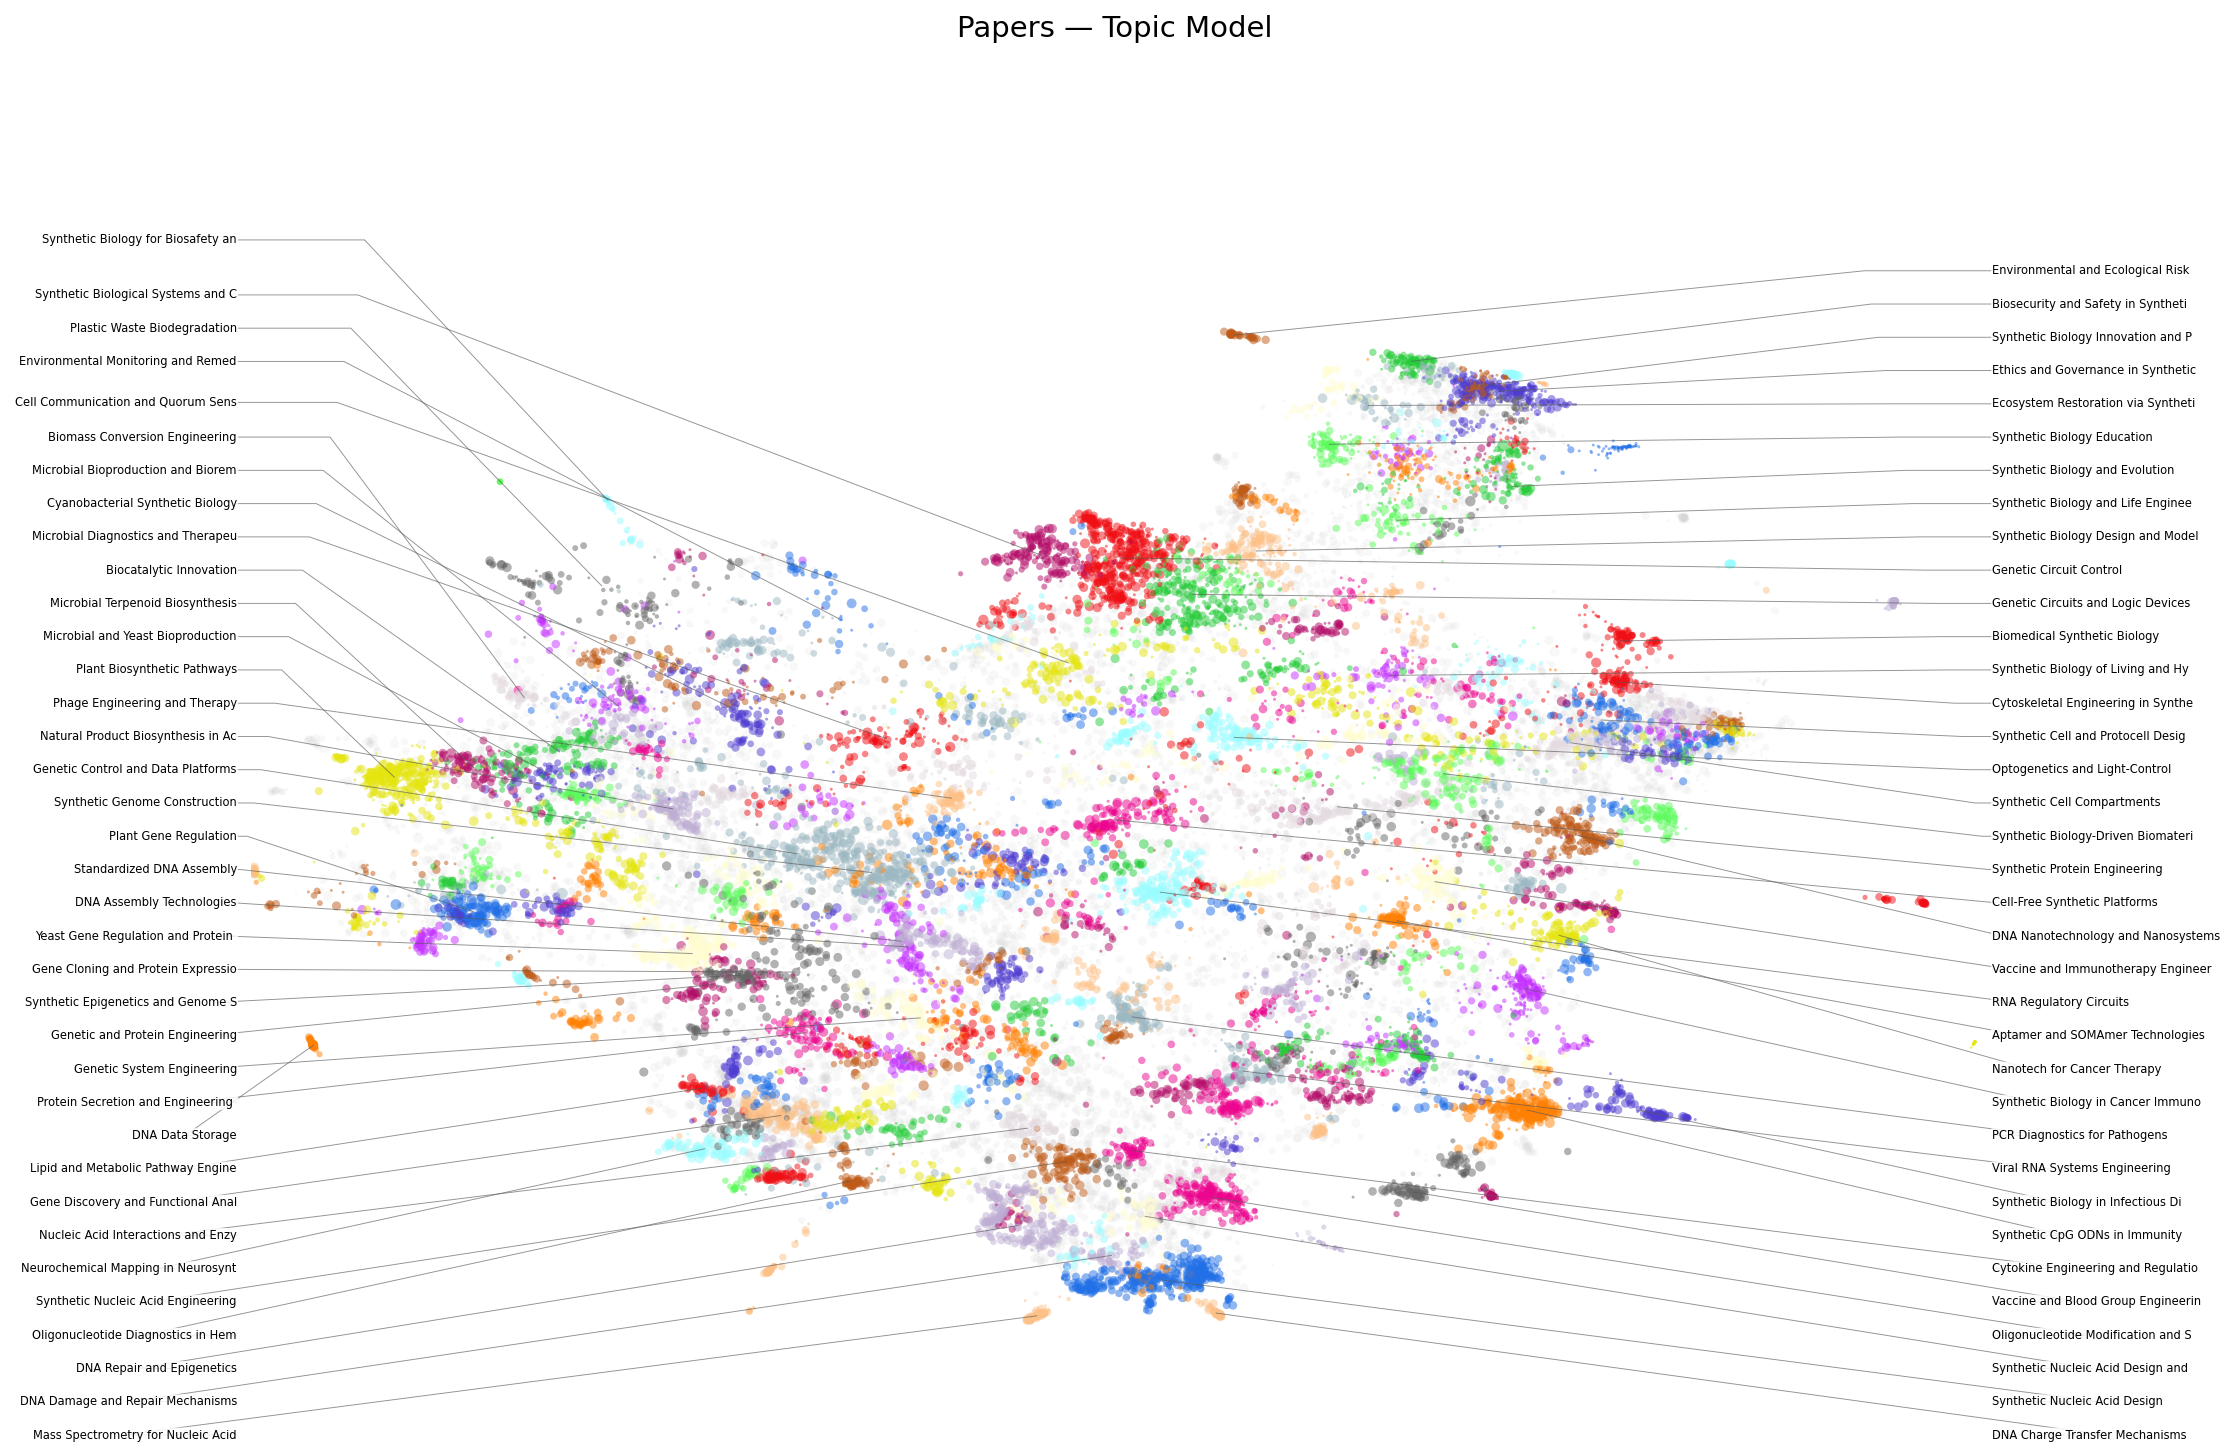

In [37]:
def _spread_targets(y_values, y_min, y_max, min_gap):
    """Spread y-positions to keep labels from overlapping."""
    if len(y_values) == 0:
        return np.array([], dtype=float)

    ys = np.array(y_values, dtype=float)
    ys = np.clip(ys, y_min, y_max)

    # Forward pass (top to bottom): enforce minimum separation
    for i in range(1, len(ys)):
        if ys[i - 1] - ys[i] < min_gap:
            ys[i] = ys[i - 1] - min_gap

    # If we fell below bounds, shift up and re-enforce constraints
    if ys[-1] < y_min:
        ys += (y_min - ys[-1])
        for i in range(len(ys) - 2, -1, -1):
            if ys[i] - ys[i + 1] < min_gap:
                ys[i] = ys[i + 1] + min_gap

    # If top exceeds bound after corrections, shift down
    if ys[0] > y_max:
        ys -= (ys[0] - y_max)

    return np.clip(ys, y_min, y_max)

def _pick_labels_for_side(sub, y_min, y_max, min_gap, max_labels=None):
    """Select a manageable, vertically spread subset of labels for one side."""
    if sub.empty:
        return sub

    capacity = max(1, int(np.floor((y_max - y_min) / min_gap)) + 1)
    target_n = capacity if max_labels is None else min(capacity, max_labels)
    target_n = min(target_n, len(sub))
    if len(sub) <= target_n:
        return sub.sort_values('cy', ascending=False).reset_index(drop=True)

    work = sub.copy()
    # Bin by y and keep the largest topic per bin to preserve vertical spread
    bins = np.linspace(y_min, y_max, target_n + 1)
    work['y_bin'] = np.clip(np.digitize(work['cy'], bins) - 1, 0, target_n - 1)
    primary = work.sort_values(['y_bin', 'n_docs'], ascending=[True, False]).groupby('y_bin', as_index=False).head(1)

    # Fill remaining slots by size if some bins were empty
    if len(primary) < target_n:
        used = set(primary.index.tolist())
        rest = work.loc[~work.index.isin(used)].sort_values('n_docs', ascending=False).head(target_n - len(primary))
        chosen = pd.concat([primary, rest], axis=0)
    else:
        chosen = primary

    return chosen.sort_values('cy', ascending=False).head(target_n).reset_index(drop=True)

def add_side_labels(ax, labels_df, xlim, ylim, min_gap_frac=0.024, text_pad_frac=0.008,
                    elbow_frac=0.004, fontsize=5.5, max_labels_per_side=None):
    """Place labels on plot sides with elbow connectors and anti-overlap spacing."""
    if labels_df.empty:
        return

    x_min, x_max = xlim
    y_min, y_max = ylim
    x_span = x_max - x_min
    y_span = y_max - y_min

    x_left = x_min - text_pad_frac * x_span
    x_right = x_max + text_pad_frac * x_span
    x_elbow_left = x_min - elbow_frac * x_span
    x_elbow_right = x_max + elbow_frac * x_span
    min_gap = min_gap_frac * y_span

    center_x = 0.5 * (x_min + x_max)
    labels = labels_df.copy()
    labels['side'] = np.where(labels['cx'] <= center_x, 'left', 'right')

    for side in ('left', 'right'):
        sub = labels[labels['side'] == side].copy()
        if sub.empty:
            continue

        sub = _pick_labels_for_side(
            sub, y_min=y_min, y_max=y_max, min_gap=min_gap, max_labels=max_labels_per_side
        )

        # Sorting by centroid y then assigning monotonic targets avoids line crossings
        sub = sub.sort_values('cy', ascending=False).reset_index(drop=True)
        sub['target_y'] = _spread_targets(sub['cy'].to_numpy(), y_min, y_max, min_gap)

        n_sub = len(sub)
        for i, (_, row) in enumerate(sub.iterrows()):
            if side == 'left':
                x_txt = x_left
                x_elb = x_elbow_left - 0.004 * x_span * (i - (n_sub - 1) / 2)
                ha = 'right'
            else:
                x_txt = x_right
                x_elb = x_elbow_right + 0.004 * x_span * (i - (n_sub - 1) / 2)
                ha = 'left'

            ax.plot(
                [row['cx'], x_elb, x_txt],
                [row['cy'], row['target_y'], row['target_y']],
                color='0.35',
                linewidth=0.45,
                alpha=0.65,
                zorder=3,
                clip_on=False,
            )

            ax.text(
                x_txt,
                row['target_y'],
                str(row['global_name'])[:34],
                fontsize=fontsize,
                ha=ha,
                va='center',
                color='black',
                bbox=dict(boxstyle='round,pad=0.12', fc='white', alpha=0.85, ec='none'),
                zorder=4,
                clip_on=False,
            )

def _stretch_xlim_from_df(df, x_col='x', pad_frac=0.002):
    """Tight x-limits to maximize horizontal usage."""
    x = pd.to_numeric(df[x_col], errors='coerce').dropna().to_numpy()
    x_min, x_max = float(np.min(x)), float(np.max(x))
    pad = max((x_max - x_min) * pad_frac, 1e-6)
    return (x_min - pad, x_max + pad)

def _compress_extreme_coordinates(df, x_col='x', y_col='y', topic_col='topic',
                                 threshold_q=98.5, shrink=0.22):
    """Compress only the most extreme points inward for cleaner plotting."""
    out = df.copy()

    base = out[out[topic_col] >= 0] if topic_col in out.columns else out
    if base.empty:
        return out

    cx = float(base[x_col].median())
    cy = float(base[y_col].median())

    sx = float(base[x_col].quantile(0.75) - base[x_col].quantile(0.25))
    sy = float(base[y_col].quantile(0.75) - base[y_col].quantile(0.25))
    sx = max(sx, 1e-6)
    sy = max(sy, 1e-6)

    dx = (out[x_col].to_numpy(dtype=float) - cx) / sx
    dy = (out[y_col].to_numpy(dtype=float) - cy) / sy
    r = np.sqrt(dx * dx + dy * dy)
    if len(r) == 0:
        return out

    r0 = float(np.percentile(r, threshold_q))
    r_new = np.where(r <= r0, r, r0 + shrink * (r - r0))
    scale = np.where(r > 0, r_new / np.maximum(r, 1e-12), 1.0)

    out[x_col] = cx + (out[x_col].to_numpy(dtype=float) - cx) * scale
    out[y_col] = cy + (out[y_col].to_numpy(dtype=float) - cy) * scale
    return out

def plot_topic_scatter(df, topics, title, size_col=None, label_min=20,
                       figsize=(12, 12), dpi=150, xlim=None, ylim=None,
                       stretch_x=True, x_pad_frac=0.002,
                       compress_extremes=True, extreme_q=98.5, extreme_shrink=0.02):
    """Reusable scatter plot for a single corpus topic model."""
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    # Visualization-only coordinate adjustment for very extreme clusters.
    plot_df = _compress_extreme_coordinates(
        df, threshold_q=extreme_q, shrink=extreme_shrink
    ) if compress_extremes else df.copy()

    # Point sizes
    if size_col and size_col in plot_df.columns:
        vals = plot_df[size_col].fillna(0).clip(lower=0)
        mx = vals.max()
        sizes = 2 + 30 * (np.log1p(vals) / np.log1p(mx)) if mx > 0 else np.full(len(plot_df), 2)
    else:
        sizes = np.full(len(plot_df), 4)

    # Outliers underneath
    omask = plot_df['topic'] == -1
    ax.scatter(plot_df.loc[omask, 'x'], plot_df.loc[omask, 'y'],
               c='#d3d3d3', s=sizes[omask] if hasattr(sizes, 'loc') else sizes[omask.values],
               alpha=0.15, edgecolors='none')
    ax.scatter(plot_df.loc[~omask, 'x'], plot_df.loc[~omask, 'y'],
               c=plot_df.loc[~omask, 'color'],
               s=sizes[~omask] if hasattr(sizes, 'loc') else sizes[~omask.values],
               alpha=0.5, edgecolors='none')

    # Stretch x by default to use horizontal space better.
    if stretch_x:
        # Use non-outlier points for x-limits so a few extremes do not waste horizontal space.
        x_source = plot_df.loc[~omask] if (~omask).any() else plot_df
        ax.set_xlim(_stretch_xlim_from_df(x_source, pad_frac=x_pad_frac))
    elif xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)

    # Build one label anchor per topic
    labels_df = plot_df[plot_df['topic'] >= 0].groupby('topic').agg(
        cx=('x', 'median'),
        cy=('y', 'median'),
        n_docs=('x', 'size'),
        global_name=('global_name', 'first'),
    ).reset_index()
    labels_df = labels_df[labels_df['n_docs'] >= label_min]

    # Place labels at left/right margins with connector lines
    cur_xlim = ax.get_xlim()
    cur_ylim = ax.get_ylim()
    add_side_labels(
        ax, labels_df, cur_xlim, cur_ylim,
        fontsize=5.5,
        max_labels_per_side=36,
    )

    ax.set_title(title, fontsize=14)
    ax.axis('off')

    # Leave minimal side gutters for external labels
    fig.subplots_adjust(left=0.02, right=0.98)
    return fig, ax

# --- Papers topic model ---
fig, ax = plot_topic_scatter(df_papers, papers_topics,
                             'Papers — Topic Model',
                             size_col='cited_by_count',
                             xlim=XLIM, ylim=YLIM)
fig.savefig(os.path.join(REPORTS, 'umap_papers.png'), dpi=150, bbox_inches='tight')
print(f"Saved → {os.path.join(REPORTS, 'umap_papers.png')}")
plt.show()

Saved → ../assets/reports/umap_teams.png


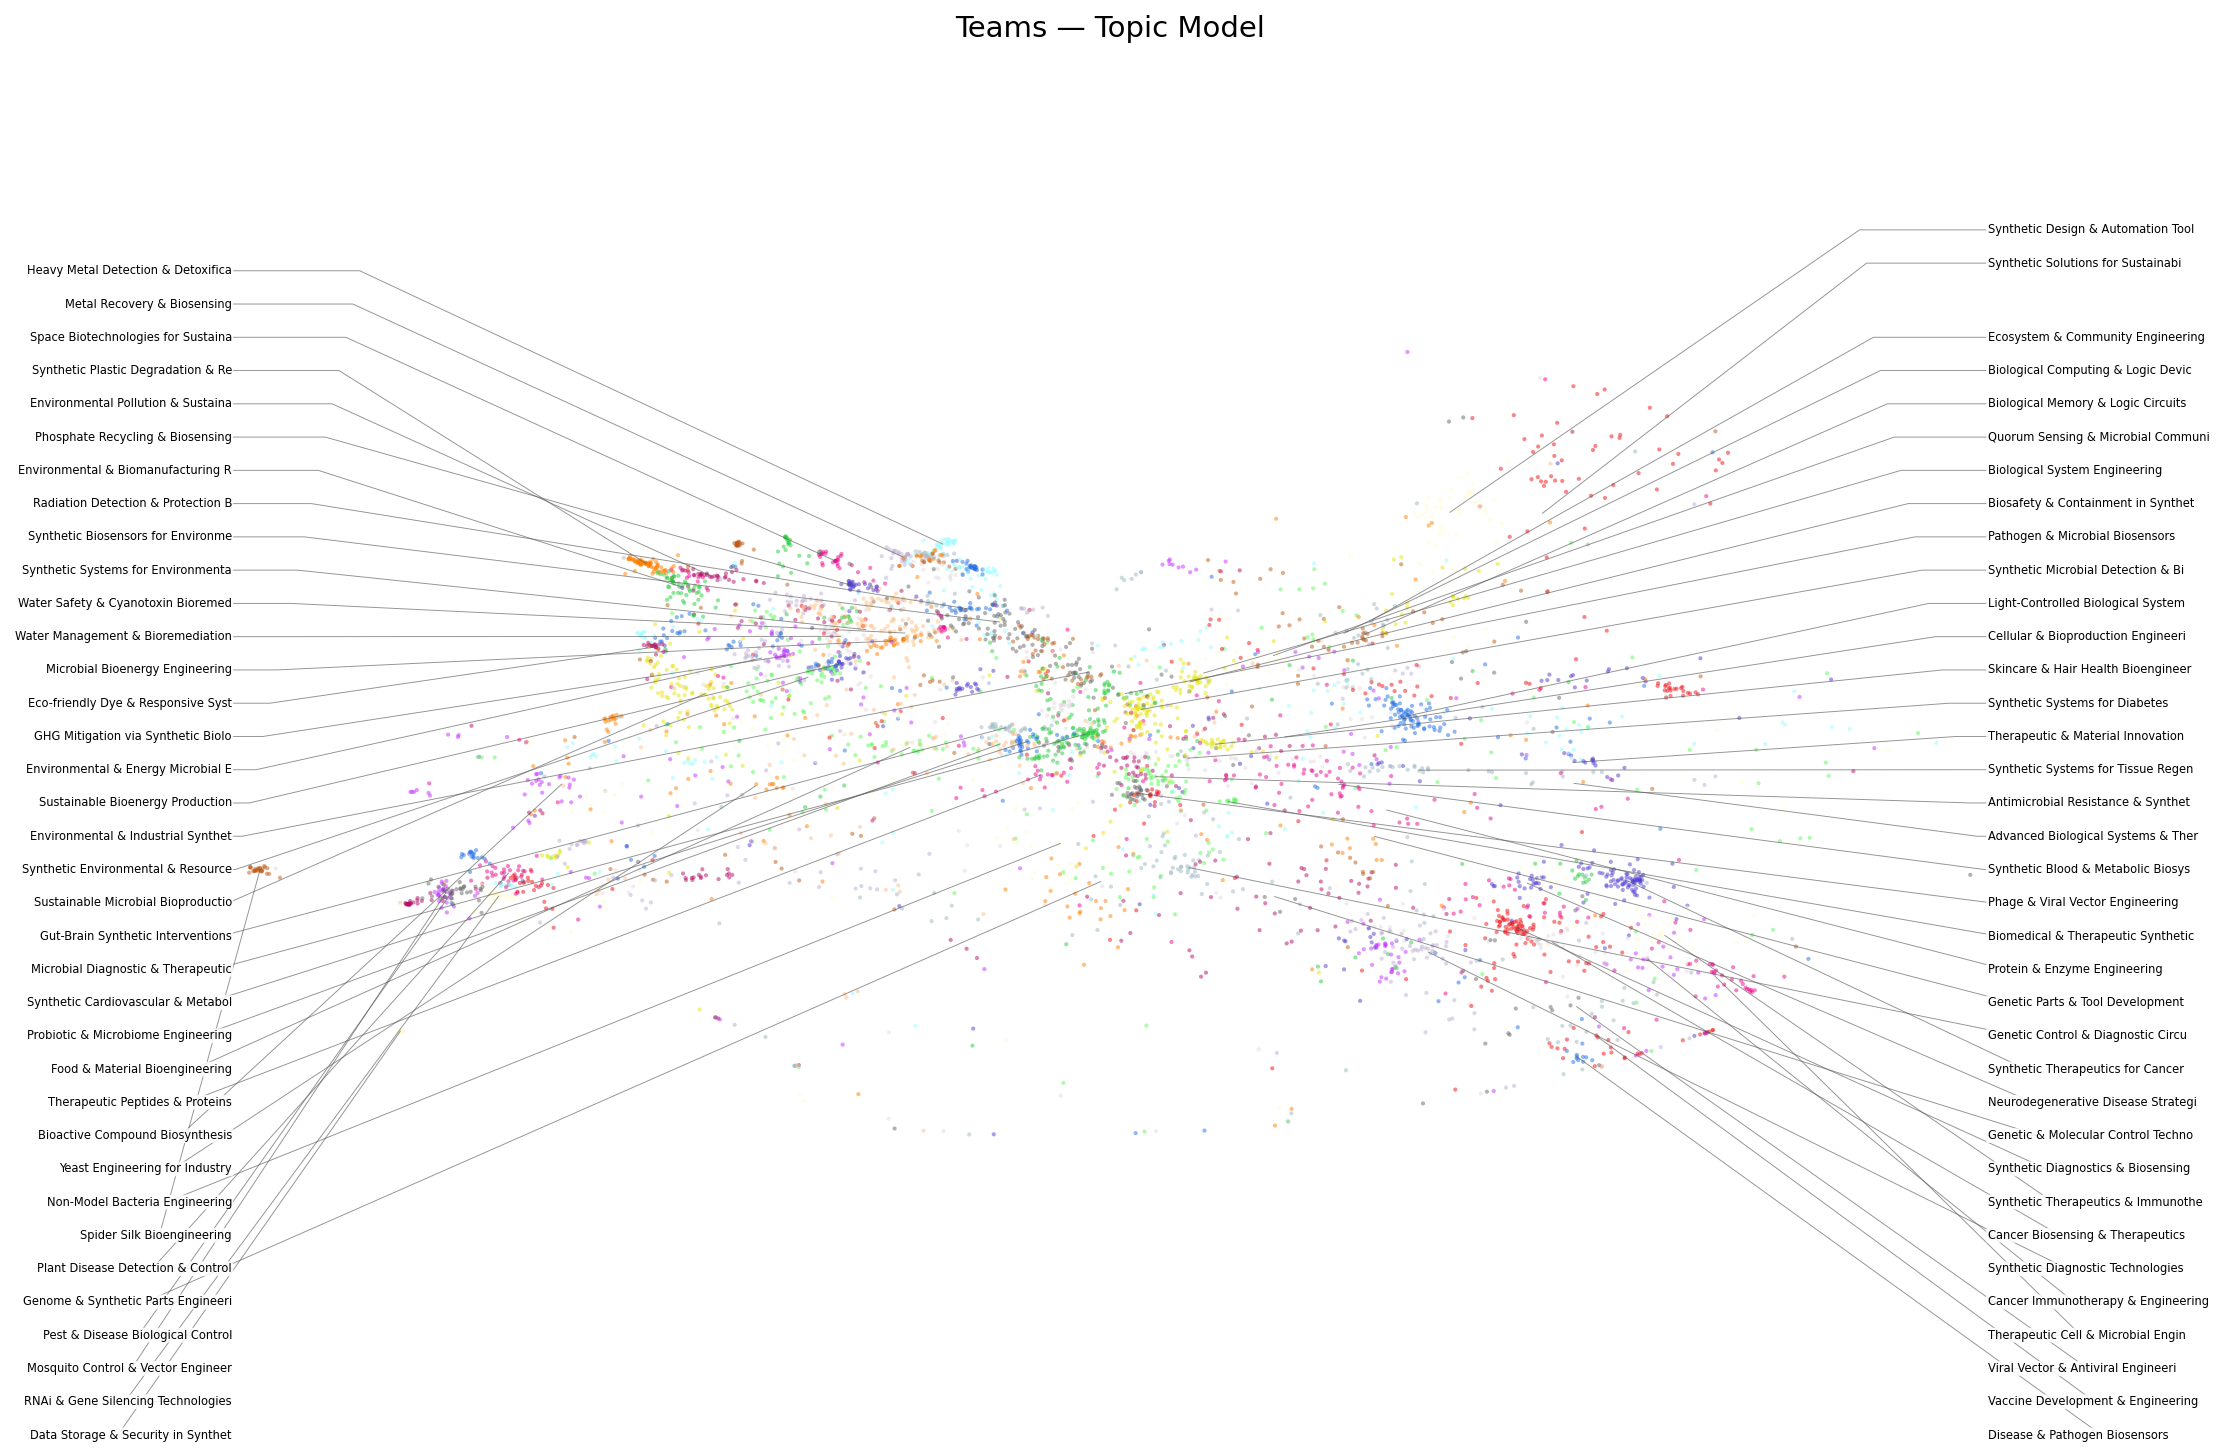

In [38]:
# --- Teams topic model ---
fig, ax = plot_topic_scatter(df_teams, teams_topics,
                             'Teams — Topic Model',
                             label_min=10,
                             xlim=XLIM, ylim=YLIM)
fig.savefig(os.path.join(REPORTS, 'umap_teams.png'), dpi=150, bbox_inches='tight')
print(f"Saved → {os.path.join(REPORTS, 'umap_teams.png')}")
plt.show()

Saved → ../assets/reports/umap_papers_toplabels.png


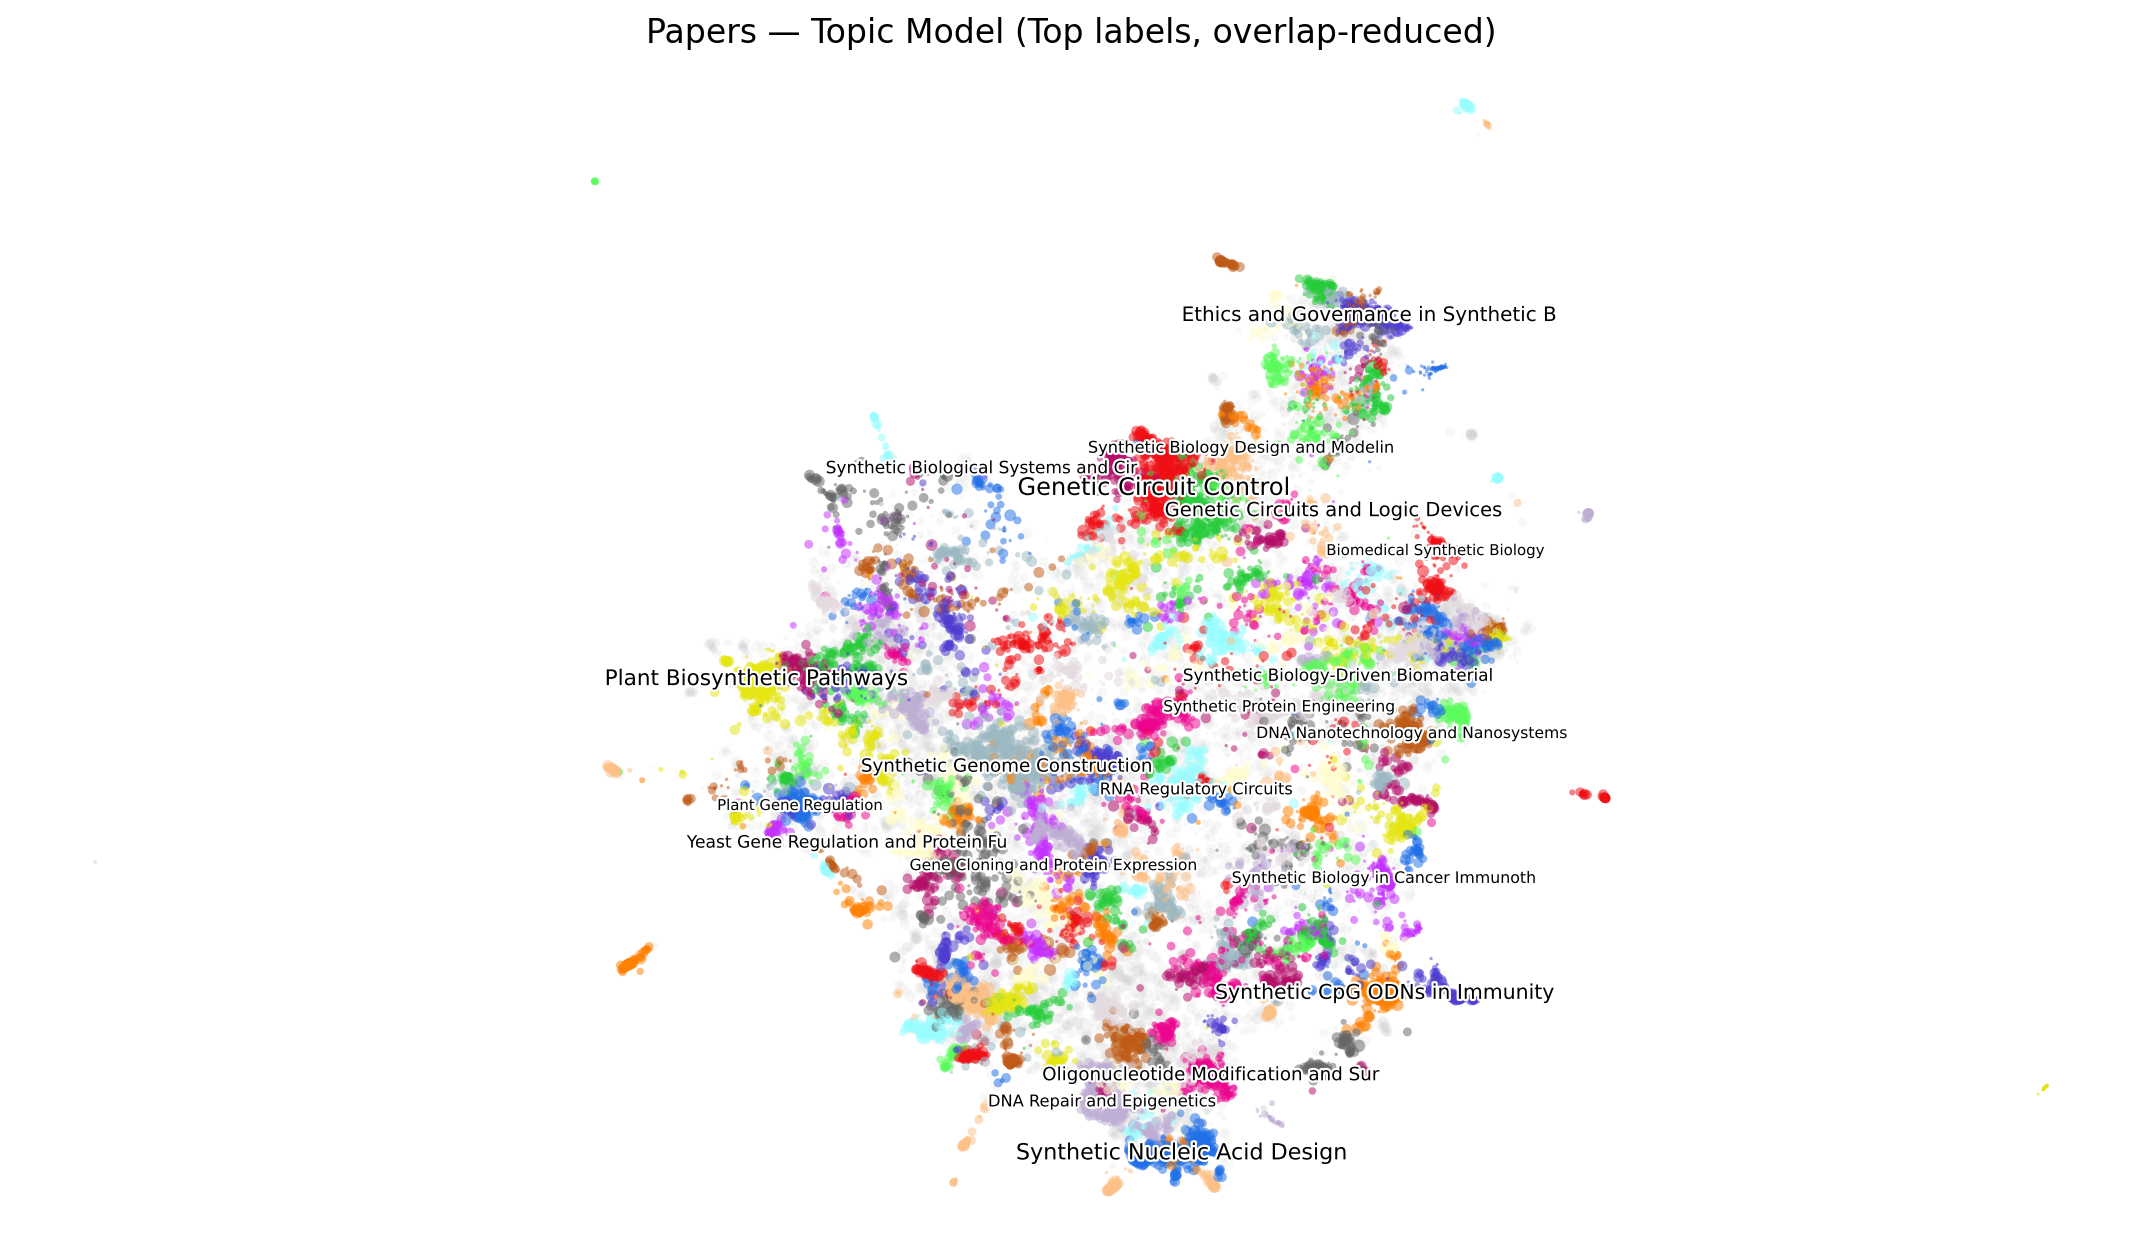

Saved → ../assets/reports/umap_teams_toplabels.png


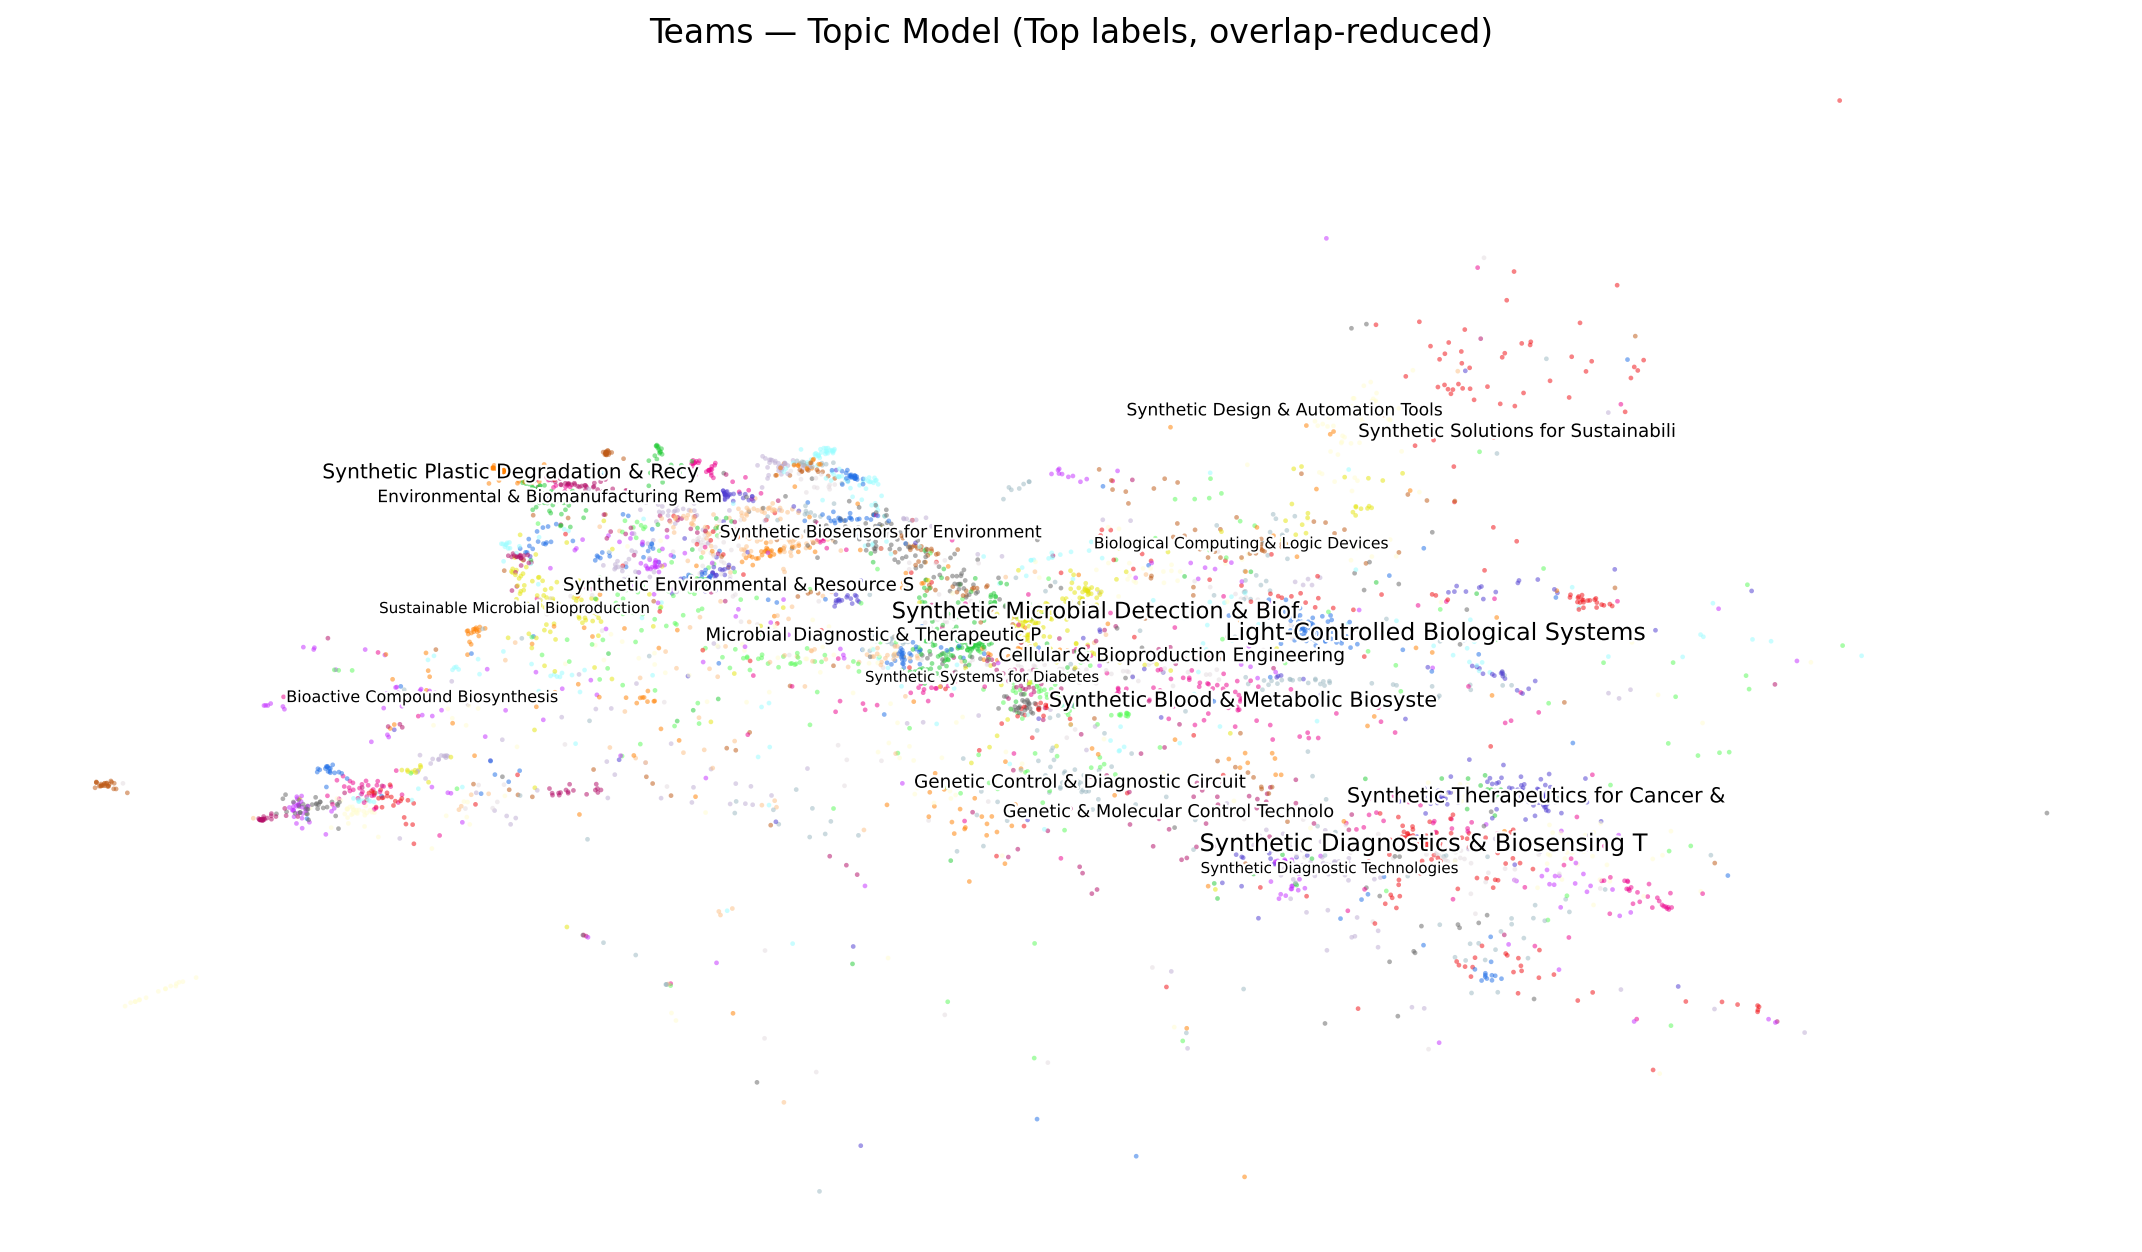

In [50]:
# --- Alternative: stretched x-axis + top labels with overlap minimization ---
import matplotlib.patheffects as pe


def _compute_stretched_limits(df, x_col='x', y_col='y', pad_frac=0.04):
    """Tight limits so embeddings use the full plotting area."""
    x = pd.to_numeric(df[x_col], errors='coerce').dropna().values
    y = pd.to_numeric(df[y_col], errors='coerce').dropna().values

    x_min, x_max = float(np.min(x)), float(np.max(x))
    y_min, y_max = float(np.min(y)), float(np.max(y))

    x_pad = max((x_max - x_min) * pad_frac, 1e-6)
    y_pad = max((y_max - y_min) * pad_frac, 1e-6)
    return (x_min - x_pad, x_max + x_pad), (y_min - y_pad, y_max + y_pad)


def _map_fontsizes(values, min_size=6.5, max_size=14.5):
    """Map cluster sizes to readable font sizes using a log scale."""
    v = np.asarray(values, dtype=float)
    if len(v) == 0:
        return np.array([], dtype=float)
    v = np.clip(v, 1, None)
    lo, hi = np.log1p(v.min()), np.log1p(v.max())
    if hi <= lo:
        return np.full_like(v, (min_size + max_size) / 2.0, dtype=float)
    s = (np.log1p(v) - lo) / (hi - lo)
    return min_size + s * (max_size - min_size)


def _relax_label_positions(anchors, labels, font_sizes, xlim, ylim, n_iter=220):
    """Simple force-based layout to reduce label overlap near cluster centers."""
    anchors = np.asarray(anchors, dtype=float)
    pos = anchors.copy()
    n = len(pos)
    if n == 0:
        return pos

    x_span = max(xlim[1] - xlim[0], 1e-9)
    y_span = max(ylim[1] - ylim[0], 1e-9)

    # Approximate text boxes in data units.
    widths = np.array([
        max(0.018, (0.50 * fs * max(len(str(lbl)), 4) / 72.0) / 14.0) * x_span
        for lbl, fs in zip(labels, font_sizes)
    ])
    heights = np.array([
        max(0.020, (1.25 * fs / 72.0) / 10.0) * y_span
        for fs in font_sizes
    ])

    for _ in range(n_iter):
        disp = np.zeros_like(pos)

        for i in range(n):
            for j in range(i + 1, n):
                dx = pos[i, 0] - pos[j, 0]
                dy = pos[i, 1] - pos[j, 1]

                overlap_x = (widths[i] + widths[j]) * 0.5 - abs(dx)
                overlap_y = (heights[i] + heights[j]) * 0.5 - abs(dy)

                if overlap_x > 0 and overlap_y > 0:
                    # Push mostly in y to preserve topic x ordering.
                    if abs(dy) < 1e-9:
                        dy = 1e-9 if i > j else -1e-9
                    if abs(dx) < 1e-9:
                        dx = 1e-9 if i < j else -1e-9

                    push_y = 0.20 * overlap_y * np.sign(dy)
                    push_x = 0.06 * overlap_x * np.sign(dx)

                    disp[i, 0] += push_x
                    disp[j, 0] -= push_x
                    disp[i, 1] += push_y
                    disp[j, 1] -= push_y

        # Pull softly toward anchors so labels stay on top of their clusters.
        disp += 0.04 * (anchors - pos)
        pos += disp

        # Keep labels inside the visible area.
        pos[:, 0] = np.clip(pos[:, 0], xlim[0] + 0.01 * x_span, xlim[1] - 0.01 * x_span)
        pos[:, 1] = np.clip(pos[:, 1], ylim[0] + 0.01 * y_span, ylim[1] - 0.01 * y_span)

    return pos


def plot_topic_scatter_top_labels(
    df,
    title,
    out_path,
    size_col=None,
    label_min=5,
    max_labels=20,
    figsize=(16, 9),
    dpi=170,
):
    """Alternative topic map: stretched x axis + top labels with overlap reduction."""
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    if size_col and size_col in df.columns:
        vals = df[size_col].fillna(0).clip(lower=0)
        mx = vals.max()
        sizes = 2 + 34 * (np.log1p(vals) / np.log1p(mx)) if mx > 0 else np.full(len(df), 2)
    else:
        sizes = np.full(len(df), 4)

    omask = df['topic'] == -1
    ax.scatter(
        df.loc[omask, 'x'],
        df.loc[omask, 'y'],
        c='#d3d3d3',
        s=sizes[omask] if hasattr(sizes, 'loc') else sizes[omask.values],
        alpha=0.15,
        edgecolors='none',
        zorder=1,
    )
    ax.scatter(
        df.loc[~omask, 'x'],
        df.loc[~omask, 'y'],
        c=df.loc[~omask, 'color'],
        s=sizes[~omask] if hasattr(sizes, 'loc') else sizes[~omask.values],
        alpha=0.52,
        edgecolors='none',
        zorder=2,
    )

    # Stretch x usage by using tight limits and a wide canvas.
    xlim, ylim = _compute_stretched_limits(df)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    labels_df = (
        df[df['topic'] >= 0]
        .groupby('topic')
        .agg(
            cx=('x', 'median'),
            cy=('y', 'median'),
            n_docs=('x', 'size'),
            global_name=('global_name', 'first'),
        )
        .reset_index()
    )
    labels_df = labels_df[labels_df['n_docs'] >= label_min].copy()
    if max_labels is not None:
        labels_df = labels_df.sort_values('n_docs', ascending=False).head(int(max_labels)).copy()

    labels = labels_df['global_name'].astype(str).str.slice(0, 36).tolist()
    font_sizes = _map_fontsizes(labels_df['n_docs'].values, min_size=6.3, max_size=10.2)
    anchors = labels_df[['cx', 'cy']].to_numpy()
    positions = _relax_label_positions(anchors, labels, font_sizes, xlim, ylim)

    for (x, y), label, fs in zip(positions, labels, font_sizes):
        txt = ax.text(
            x,
            y,
            label,
            fontsize=float(fs),
            color='black',
            ha='center',
            va='center',
            zorder=6,
        )
        txt.set_path_effects([
            pe.Stroke(linewidth=max(1.9, fs * 0.18), foreground='white'),
            pe.Normal(),
        ])

    ax.set_title(title, fontsize=14)
    ax.axis('off')
    fig.savefig(out_path, dpi=dpi, bbox_inches='tight')
    print(f"Saved → {out_path}")
    plt.show()


# Papers alternative
plot_topic_scatter_top_labels(
    df_papers,
    title='Papers — Topic Model (Top labels, overlap-reduced)',
    out_path=os.path.join(REPORTS, 'umap_papers_toplabels.png'),
    size_col='cited_by_count',
    label_min=20,
)

# Teams alternative
plot_topic_scatter_top_labels(
    df_teams,
    title='Teams — Topic Model (Top labels, overlap-reduced)',
    out_path=os.path.join(REPORTS, 'umap_teams_toplabels.png'),
    label_min=10,
)


Saved → ../assets/reports/umap_overlay.png


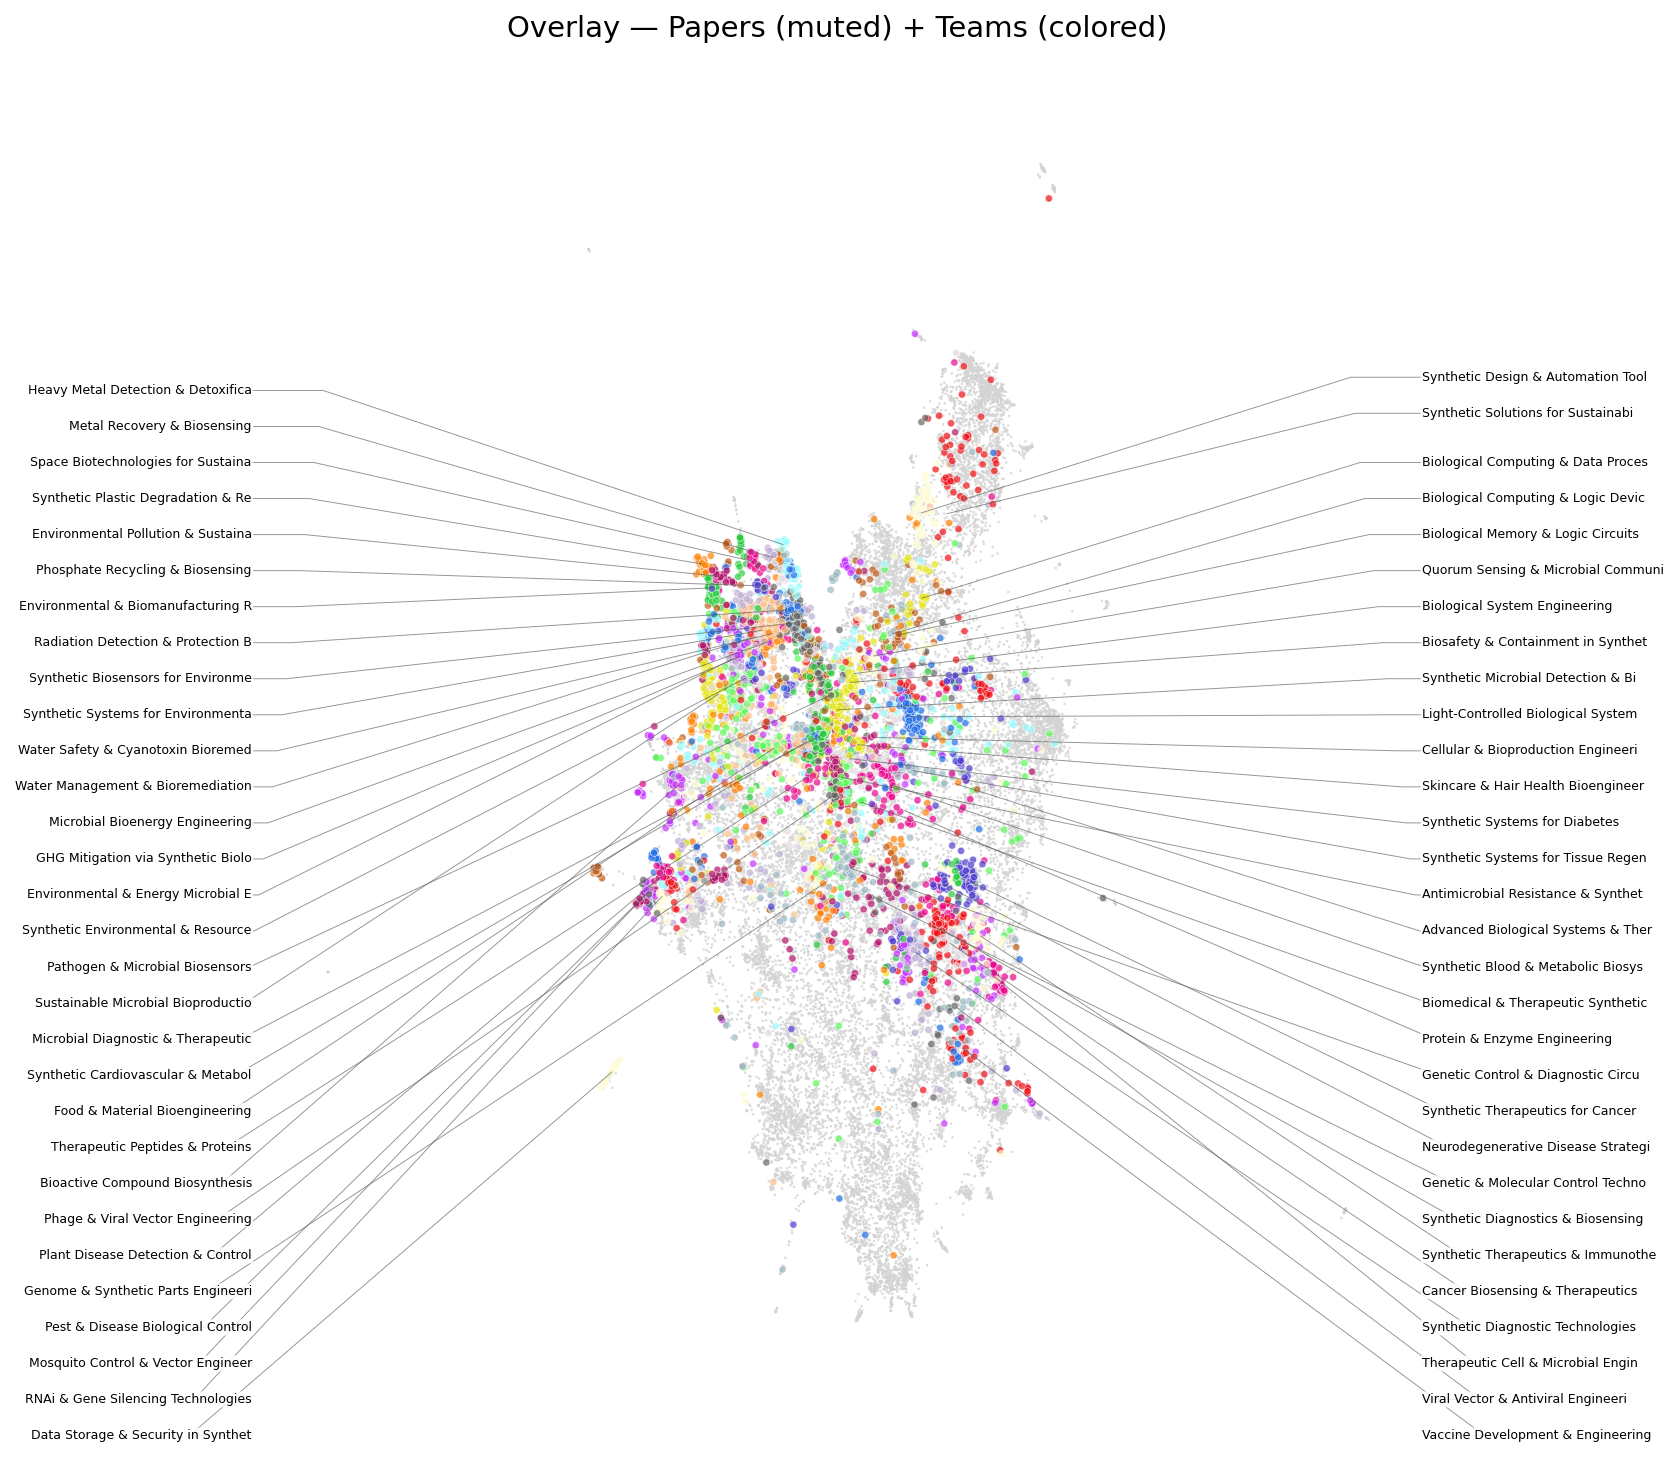

In [40]:
# --- Overlay: papers (muted) + teams (on top, side-labelled) ---
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

# Papers layer — muted grey, no labels
ax.scatter(df_papers['x'], df_papers['y'],
           c='#d3d3d3', s=1.5, alpha=0.8, edgecolors='none')

# Teams layer — full color
omask_t = df_teams['topic'] == -1
ax.scatter(df_teams.loc[omask_t, 'x'], df_teams.loc[omask_t, 'y'],
           c='#a0a0a0', s=6, alpha=0.25, edgecolors='none')
ax.scatter(df_teams.loc[~omask_t, 'x'], df_teams.loc[~omask_t, 'y'],
           c=df_teams.loc[~omask_t, 'color'], s=12,
           alpha=0.7, edgecolors='white', linewidth=0.3)

# Teams labels (side placement with anti-overlap)
teams_labels = df_teams[df_teams['topic'] >= 0].groupby('topic').agg(
    cx=('x', 'median'),
    cy=('y', 'median'),
    n_docs=('x', 'size'),
    global_name=('global_name', 'first'),
).reset_index()
teams_labels = teams_labels[teams_labels['n_docs'] >= 10]
add_side_labels(
    ax, teams_labels, XLIM, YLIM,
    fontsize=6,
    min_gap_frac=0.026,
    max_labels_per_side=30,
)

ax.set_xlim(XLIM)
ax.set_ylim(YLIM)
ax.set_title('Overlay — Papers (muted) + Teams (colored)', fontsize=14)
ax.axis('off')
fig.subplots_adjust(left=0.18, right=0.82)
fig.savefig(os.path.join(REPORTS, 'umap_overlay.png'), dpi=150, bbox_inches='tight')
print(f"Saved → {os.path.join(REPORTS, 'umap_overlay.png')}")
plt.show()

## Density ratio map — Papers vs Teams

We estimate kernel density for each corpus on the same 2D grid, then plot `log₂(teams_density / papers_density)`:
- **Red** regions = teams-dense relative to papers → iGEM activity *ahead* of the literature
- **Blue** regions = papers-dense relative to teams → academic knowledge *not yet adopted* by iGEM
- **White/neutral** = balanced coverage

This directly maps the science–practice gap onto the joint topic space.

In [41]:
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter

# KDE for each corpus (using all points including outliers — we want spatial density)
kde_papers = gaussian_kde(papers_xy.T, bw_method=0.15)
kde_teams  = gaussian_kde(teams_xy.T,  bw_method=0.15)

# Build evaluation grid (reuse shared XLIM/YLIM)
x_min, x_max = XLIM
y_min, y_max = YLIM
grid_res = 300
xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_res),
                      np.linspace(y_min, y_max, grid_res))
grid_pts = np.vstack([xx.ravel(), yy.ravel()])

# Evaluate densities (normalize to sum to 1 so ratio is scale-independent)
p = kde_papers(grid_pts)
q = kde_teams(grid_pts)
p /= p.sum()
q /= q.sum()

# Log₂ density ratio
eps = 1e-12
ratio = np.log2((q + eps) / (p + eps))
ratio_grid = ratio.reshape(xx.shape)

# Symmetric clipping so the colorscale is centered at 0
vmax = np.percentile(np.abs(ratio_grid), 98)
ratio_grid = np.clip(ratio_grid, -vmax, vmax)

# Smooth per-pixel alpha based on combined density.
# Instead of a hard binary mask, the alpha channel fades smoothly
# from 1 (where data is dense) to 0 (empty space) — no abrupt edges.
p_grid = p.reshape(xx.shape)
q_grid = q.reshape(xx.shape)
combined = p_grid + q_grid
alpha_grid = combined / np.percentile(combined, 95)   # saturate at 95th pctl
alpha_grid = np.clip(alpha_grid, 0, 1)
alpha_grid = gaussian_filter(alpha_grid, sigma=3)      # extra smoothing

print(f"Grid: {grid_res}x{grid_res}, ratio range clipped to ±{vmax:.1f}")

Grid: 300x300, ratio range clipped to ±19.4


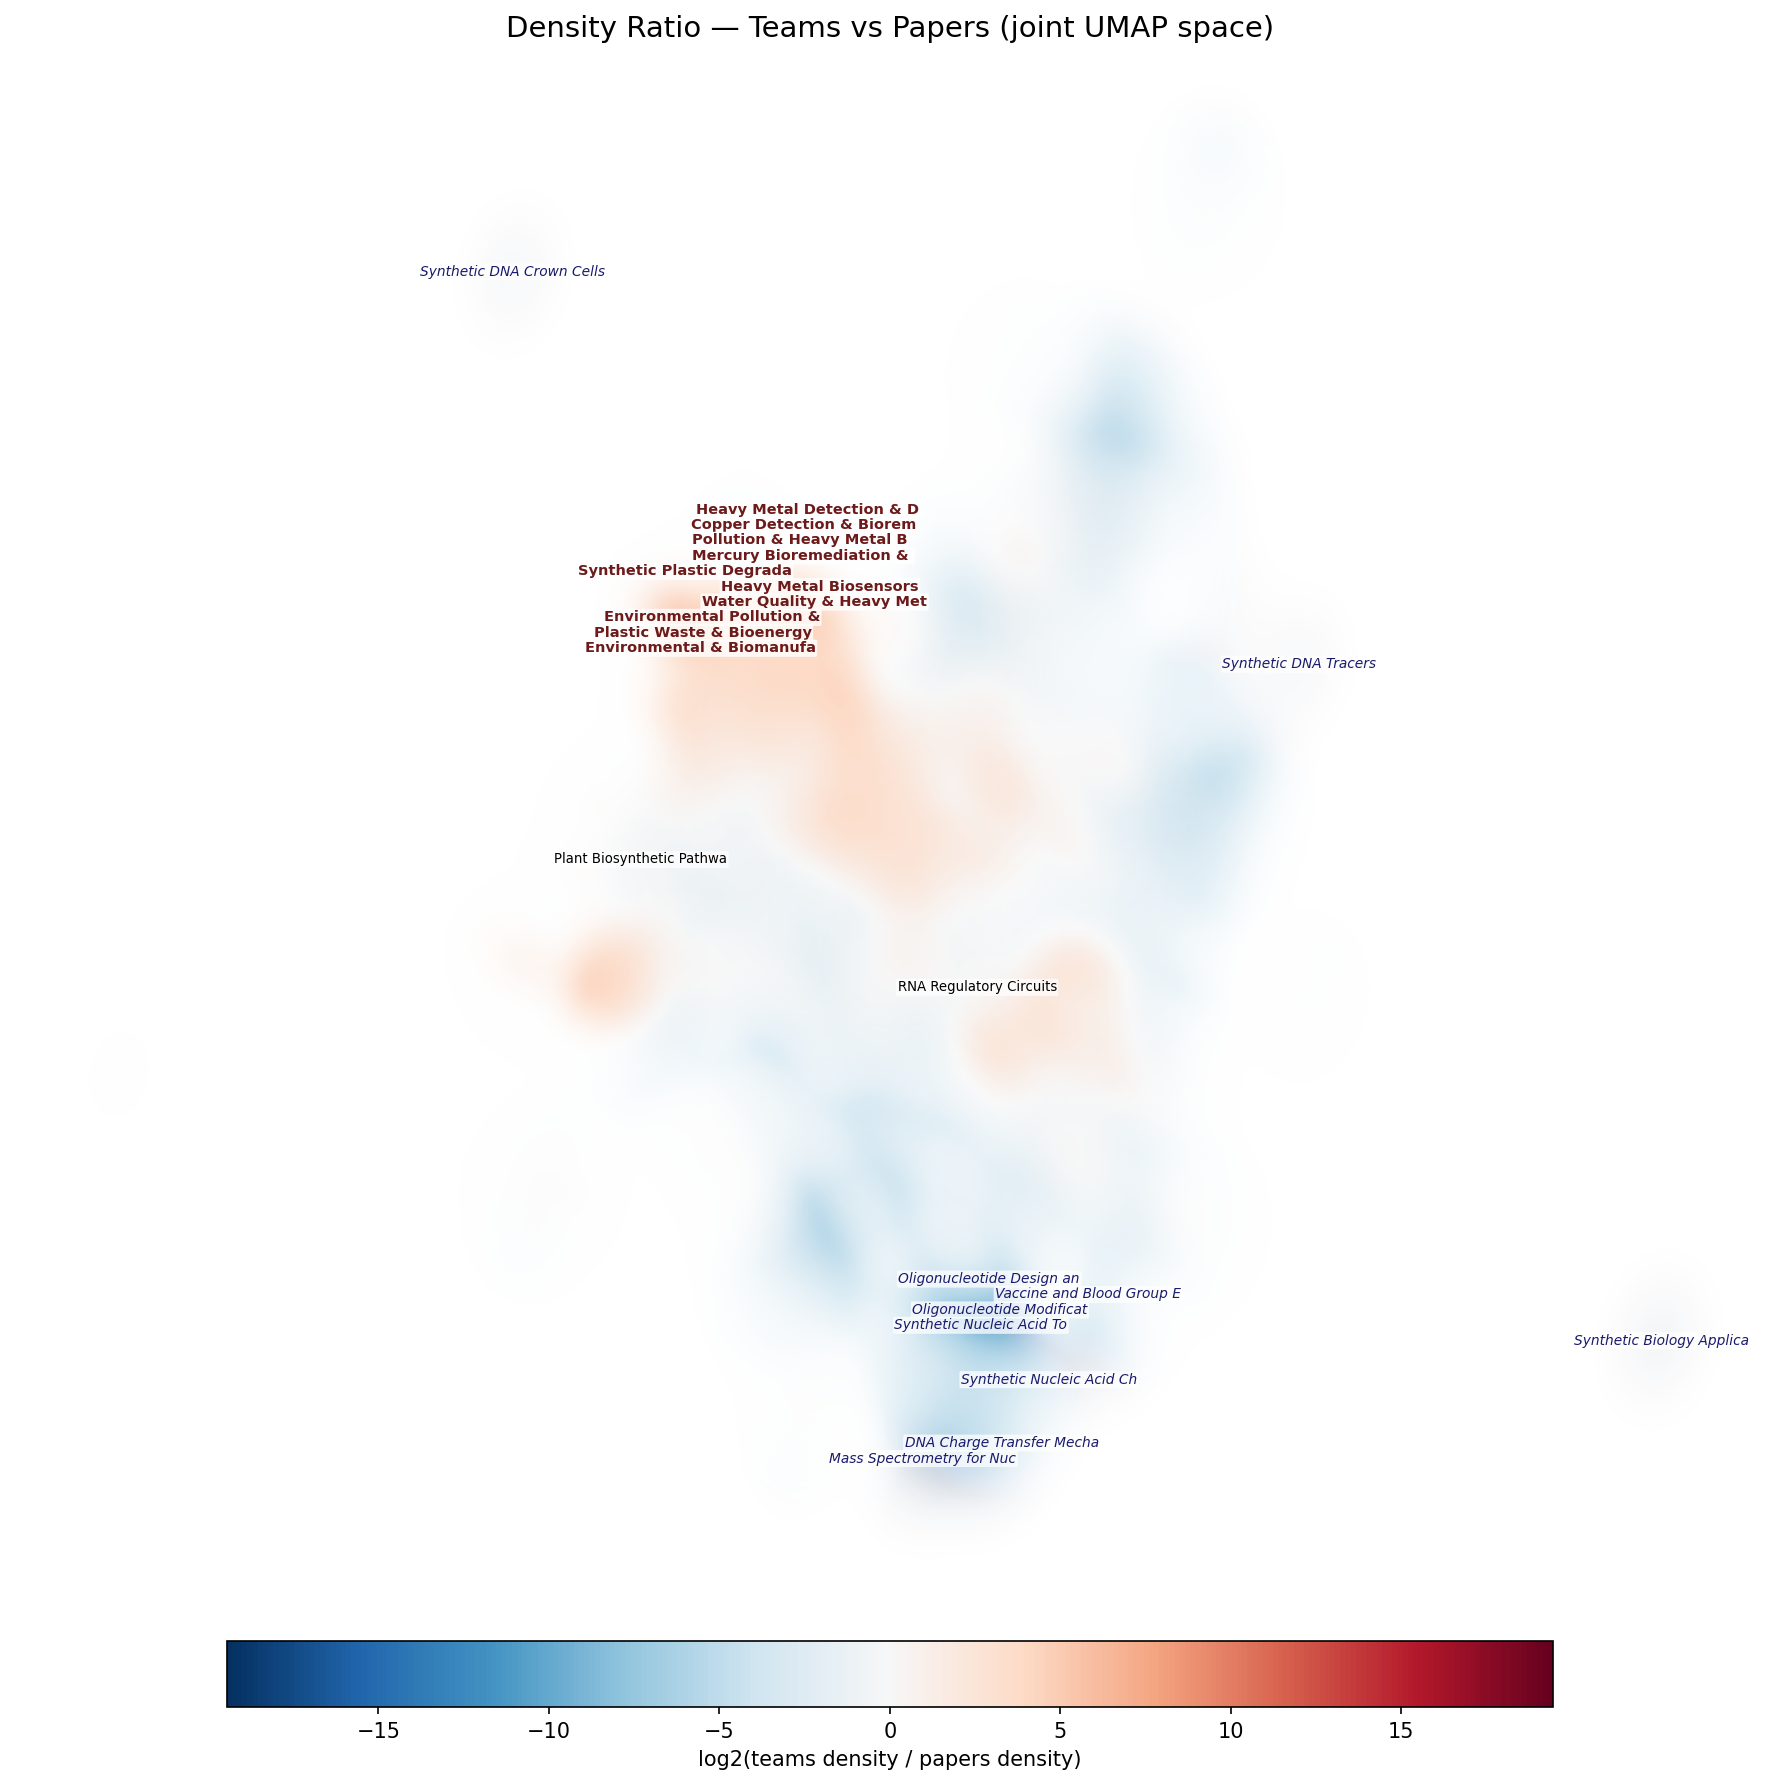

In [48]:
# --- Density ratio heatmap (smooth alpha fade, readability-focused labels) ---
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

# Build RGBA image from the RdBu_r colormap + density-based alpha
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
cmap = plt.cm.RdBu_r
rgba = cmap(norm(ratio_grid))        # shape (H, W, 4)
rgba[..., 3] = alpha_grid            # replace alpha with density fade

ax.imshow(
    rgba,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    aspect='auto',
    interpolation='bilinear',
)

# Dummy ScalarMappable for colorbar (imshow RGBA has no built-in one)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.04, pad=0.03)
cbar.set_label('log2(teams density / papers density)', fontsize=10)

# --- Label selection logic ---
# Compute per-topic density ratio at centroid for both teams and papers
from scipy.interpolate import RegularGridInterpolator
ratio_interp = RegularGridInterpolator(
    (np.linspace(y_min, y_max, grid_res), np.linspace(x_min, x_max, grid_res)),
    np.ma.filled(ratio_grid, fill_value=0),
    method='linear', bounds_error=False, fill_value=0
)

# Teams topic centroids
teams_ctr = df_teams[df_teams['topic'] >= 0].groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'), n_docs=('x', 'size'), global_name=('global_name', 'first')
).reset_index()
teams_ctr['log2_ratio'] = ratio_interp(np.column_stack([teams_ctr['cy'], teams_ctr['cx']]))

# Papers topic centroids
papers_ctr = df_papers[df_papers['topic'] >= 0].groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'), n_docs=('x', 'size'), global_name=('global_name', 'first')
).reset_index()
papers_ctr['log2_ratio'] = ratio_interp(np.column_stack([papers_ctr['cy'], papers_ctr['cx']]))

# Show fewer labels for readability
N = 10
show_teams = teams_ctr.sort_values('log2_ratio', ascending=False).head(N)
show_papers = papers_ctr.sort_values('log2_ratio', ascending=True).head(N)
overlap = papers_ctr.loc[(papers_ctr['log2_ratio'].abs() < 0.5)].sort_values('n_docs', ascending=False).head(2)


def _relax_density_labels(labels_df, xlim, ylim, n_iter=260, y_min_gap_frac=0.01):
    """Force layout with extra y-axis spreading for crowded labels."""
    if labels_df.empty:
        return np.empty((0, 2), dtype=float)

    anchors = labels_df[['cx', 'cy']].to_numpy(dtype=float)
    pos = anchors.copy()

    x_span = max(xlim[1] - xlim[0], 1e-9)
    y_span = max(ylim[1] - ylim[0], 1e-9)
    y_min_gap = y_min_gap_frac * y_span

    widths = np.array([
        max(0.025, 0.0058 * len(str(lbl)) + 0.004 * fs) * x_span / 12.0
        for lbl, fs in zip(labels_df['label'].tolist(), labels_df['fontsize'].to_numpy(dtype=float))
    ])
    heights = np.array([
        max(0.020, 0.0035 * fs) * y_span / 12.0
        for fs in labels_df['fontsize'].to_numpy(dtype=float)
    ])

    for _ in range(n_iter):
        disp = np.zeros_like(pos)
        for i in range(len(pos)):
            for j in range(i + 1, len(pos)):
                dx = pos[i, 0] - pos[j, 0]
                dy = pos[i, 1] - pos[j, 1]

                ox = 0.5 * (widths[i] + widths[j]) - abs(dx)
                oy = 0.5 * (heights[i] + heights[j]) - abs(dy)

                if ox > 0 and oy > 0:
                    sx = np.sign(dx) if abs(dx) > 1e-10 else (1 if i > j else -1)
                    sy = np.sign(dy) if abs(dy) > 1e-10 else (1 if i > j else -1)
                    disp[i, 0] += 0.07 * ox * sx
                    disp[j, 0] -= 0.07 * ox * sx
                    disp[i, 1] += 0.36 * oy * sy
                    disp[j, 1] -= 0.36 * oy * sy

        # Weaker x pull, stronger y pull back to anchors.
        disp[:, 0] += 0.02 * (anchors[:, 0] - pos[:, 0])
        disp[:, 1] += 0.07 * (anchors[:, 1] - pos[:, 1])
        pos += disp

        # Explicit y spreading pass to enforce readable vertical separation.
        order = np.argsort(pos[:, 1])
        for k in range(1, len(order)):
            prev_i = order[k - 1]
            cur_i = order[k]
            min_y = pos[prev_i, 1] + y_min_gap
            if pos[cur_i, 1] < min_y:
                pos[cur_i, 1] = min_y

        y_low = ylim[0] + 0.01 * y_span
        y_high = ylim[1] - 0.01 * y_span
        if len(order) > 0 and pos[order[-1], 1] > y_high:
            pos[:, 1] -= (pos[order[-1], 1] - y_high)
            for k in range(len(order) - 2, -1, -1):
                upper_i = order[k + 1]
                cur_i = order[k]
                max_y = pos[upper_i, 1] - y_min_gap
                if pos[cur_i, 1] > max_y:
                    pos[cur_i, 1] = max_y

        pos[:, 0] = np.clip(pos[:, 0], xlim[0] + 0.01 * x_span, xlim[1] - 0.01 * x_span)
        pos[:, 1] = np.clip(pos[:, 1], y_low, y_high)

    return pos


# Build label table with style metadata
label_rows = []
for _, row in show_teams.iterrows():
    label_rows.append({
        'cx': row['cx'], 'cy': row['cy'], 'label': str(row['global_name'])[:25], 'fontsize': 7.0,
        'color': '#6c1a1a', 'fontstyle': 'normal', 'fontweight': 'bold', 'box_alpha': 0.78,
    })
for _, row in show_papers.iterrows():
    label_rows.append({
        'cx': row['cx'], 'cy': row['cy'], 'label': str(row['global_name'])[:25], 'fontsize': 6.6,
        'color': '#1a1a6c', 'fontstyle': 'italic', 'fontweight': 'normal', 'box_alpha': 0.74,
    })
for _, row in overlap.iterrows():
    label_rows.append({
        'cx': row['cx'], 'cy': row['cy'], 'label': str(row['global_name'])[:25], 'fontsize': 6.4,
        'color': 'black', 'fontstyle': 'normal', 'fontweight': 'normal', 'box_alpha': 0.72,
    })

labels_plot = pd.DataFrame(label_rows)
if not labels_plot.empty:
    pos = _relax_density_labels(labels_plot, xlim=XLIM, ylim=YLIM)
    for (x, y), (_, row) in zip(pos, labels_plot.iterrows()):
        ax.text(
            x, y, row['label'],
            fontsize=float(row['fontsize']),
            fontstyle=row['fontstyle'],
            fontweight=row['fontweight'],
            ha='center', va='center', color=row['color'],
            bbox=dict(boxstyle='round,pad=0.11', fc='white', alpha=float(row['box_alpha']), ec='none')
        )

ax.set_xlim(XLIM)
ax.set_ylim(YLIM)
ax.set_title('Density Ratio — Teams vs Papers (joint UMAP space)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
# --- Quantitative overlap metrics ---

from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree

# -- Helper: year summary stats for a 1D numeric series --
def summarize_years(values, prefix):
    """Return min, q1, mean, median, q3, max with a prefix in column names."""
    s = pd.Series(values).dropna().astype(float)
    if s.empty:
        return {
            f'{prefix}_min_year': np.nan,
            f'{prefix}_q1_year': np.nan,
            f'{prefix}_mean_year': np.nan,
            f'{prefix}_median_year': np.nan,
            f'{prefix}_q3_year': np.nan,
            f'{prefix}_max_year': np.nan,
        }
    return {
        f'{prefix}_min_year': round(float(s.min()), 2),
        f'{prefix}_q1_year': round(float(s.quantile(0.25)), 2),
        f'{prefix}_mean_year': round(float(s.mean()), 2),
        f'{prefix}_median_year': round(float(s.median()), 2),
        f'{prefix}_q3_year': round(float(s.quantile(0.75)), 2),
        f'{prefix}_max_year': round(float(s.max()), 2),
    }

# -- 1. Interpolate pre-computed ratio grid at topic centroids --
#    Avoids expensive per-topic KDE evaluation and just samples the grid.
x_vals = np.linspace(*XLIM, grid_res)
y_vals = np.linspace(*YLIM, grid_res)
ratio_filled = np.ma.filled(ratio_grid, fill_value=np.nan)
ratio_interp = RegularGridInterpolator(
    (y_vals, x_vals), ratio_filled,
    method='linear', bounds_error=False, fill_value=np.nan
)

# -- 2. Papers topic centroids + density ratio --
_df_p = df_papers[df_papers['topic'] >= 0].copy()
_df_p = _df_p.merge(papers[['id', 'publication_year']], on='id', how='left')

papers_ctr = _df_p.groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'),
    n_docs=('x', 'size'),
    avg_year=('publication_year', 'mean'),
    global_name=('global_name', 'first'),
).reset_index()
papers_ctr['log2_ratio'] = ratio_interp(
    np.column_stack([papers_ctr['cy'].values, papers_ctr['cx'].values])
)

# -- 3. Teams topic centroids + density ratio --
teams_raw = pd.read_csv(os.path.join(ASSETS, 'igem.txt'), sep='\t', usecols=['UT', 'Year_y'])
teams_raw['Year_y'] = pd.to_numeric(teams_raw['Year_y'], errors='coerce')

_df_t = df_teams[df_teams['topic'] >= 0].copy()
_df_t = _df_t.merge(teams_raw, on='UT', how='left')

teams_ctr = _df_t.groupby('topic').agg(
    cx=('x', 'median'), cy=('y', 'median'),
    n_docs=('x', 'size'),
    avg_year=('Year_y', 'mean'),
    global_name=('global_name', 'first'),
).reset_index()
teams_ctr['log2_ratio'] = ratio_interp(
    np.column_stack([teams_ctr['cy'].values, teams_ctr['cx'].values])
)

# -- 4. Classify topics by coverage zone --
#    |log2_ratio| > 1 means one corpus has >2x the density of the other.
def classify(r):
    if pd.isna(r):
        return 'unmapped'
    if r > 1:
        return 'teams-dominant'
    if r < -1:
        return 'papers-only'
    return 'overlap'

papers_ctr['zone'] = papers_ctr['log2_ratio'].apply(classify)
teams_ctr['zone'] = teams_ctr['log2_ratio'].apply(classify)

print('=== Papers topics by zone ===')
print(papers_ctr['zone'].value_counts().to_string())
print('\n=== Teams topics by zone ===')
print(teams_ctr['zone'].value_counts().to_string())

# -- 5. Temporal precedence for overlap papers topics --
#    For each overlap paper topic, find nearby teams in UMAP space
#    and compare year distributions.
teams_tree = cKDTree(teams_xy)
_df_t_full = df_teams.merge(teams_raw, on='UT', how='left')

precedence = []
overlap_topics = papers_ctr[papers_ctr['zone'] == 'overlap']

for _, row in overlap_topics.iterrows():
    # Search radius: median intra-cluster distance x 1.5
    topic_pts = _df_p.loc[_df_p['topic'] == row['topic'], ['x', 'y']].values
    dists = np.sqrt((topic_pts[:, 0] - row['cx'])**2 +
                    (topic_pts[:, 1] - row['cy'])**2)
    radius = np.median(dists) * 1.5

    nearby_idx = teams_tree.query_ball_point([row['cx'], row['cy']], r=radius)

    # Actual years used for summary statistics
    paper_years = _df_p.loc[_df_p['topic'] == row['topic'], 'publication_year'].dropna()
    nearby_years = _df_t_full.iloc[nearby_idx]['Year_y'].dropna()

    # Require enough nearby teams and at least one paper year
    if len(nearby_years) < 3 or len(paper_years) == 0:
        continue

    p_stats = summarize_years(paper_years, prefix='papers')
    t_stats = summarize_years(nearby_years, prefix='teams')

    rec = {
        'topic': row['topic'],
        'global_name': row['global_name'],
        'n_papers': int(row['n_docs']),
        'n_nearby_teams': int(len(nearby_idx)),
    }
    rec.update(p_stats)
    rec.update(t_stats)

    # Delta columns: teams minus papers for each summary statistic
    for stat in ('min', 'q1', 'mean', 'median', 'q3', 'max'):
        rec[f'delta_{stat}_years'] = round(
            rec[f'teams_{stat}_year'] - rec[f'papers_{stat}_year'],
            2,
        )

    precedence.append(rec)

df_prec = pd.DataFrame(precedence).sort_values('delta_mean_years')

print(f"\n{'=' * 72}")
print(f"Temporal precedence - {len(df_prec)} overlap topics with nearby teams")
print('  delta_*_years < 0 -> iGEM teams PRECEDED the literature')
print('  delta_*_years > 0 -> literature PRECEDED iGEM teams')
print(f"{'=' * 72}")

# Compact console view (full metrics are saved in TSV files)
cols = [
    'global_name', 'n_papers', 'n_nearby_teams',
    'papers_mean_year', 'teams_mean_year', 'delta_mean_years',
    'papers_median_year', 'teams_median_year', 'delta_median_years',
]

print(f"\niGEM preceded by mean ({(df_prec['delta_mean_years'] < 0).sum()} topics):")
print(df_prec[df_prec['delta_mean_years'] < 0].head(15)[cols].to_string(index=False))
print(f"\nLiterature preceded by mean ({(df_prec['delta_mean_years'] > 0).sum()} topics):")
print(df_prec[df_prec['delta_mean_years'] > 0].tail(15)[cols].to_string(index=False))

# -- 6. Save tables to assets/reports/ --
REPORTS = os.path.join(ASSETS, 'reports')
os.makedirs(REPORTS, exist_ok=True)

# Save full overlap precedence table
df_prec.to_csv(os.path.join(REPORTS, 'overlap_precedence_full.tsv'), sep='\t', index=False)

df_igem_preceded = df_prec[df_prec['delta_mean_years'] < 0].copy()
df_lit_preceded = df_prec[df_prec['delta_mean_years'] > 0].copy()

df_igem_preceded.to_csv(os.path.join(REPORTS, 'igem_preceded.tsv'), sep='\t', index=False)
df_lit_preceded.to_csv(os.path.join(REPORTS, 'literature_preceded.tsv'), sep='\t', index=False)

print(f"\nSaved to {REPORTS}/:")
print(f"  overlap_precedence_full.tsv ({len(df_prec)} rows)")
print(f"  igem_preceded.tsv           ({len(df_igem_preceded)} rows)")
print(f"  literature_preceded.tsv     ({len(df_lit_preceded)} rows)")

=== Papers topics by zone ===
zone
papers-only       148
overlap            83
teams-dominant     32

=== Teams topics by zone ===
zone
teams-dominant    115
overlap            44
papers-only         2

Temporal precedence - 70 overlap topics with nearby teams
  delta_*_years < 0 -> iGEM teams PRECEDED the literature
  delta_*_years > 0 -> literature PRECEDED iGEM teams

iGEM preceded by mean (34 topics):
                                     global_name  n_papers  n_nearby_teams  papers_mean_year  teams_mean_year  delta_mean_years  papers_median_year  teams_median_year  delta_median_years
                         AI in Synthetic Biology        27              21           2022.81          2016.86             -5.95              2024.0             2017.0                -7.0
                   Microbial Chassis Development        25               9           2018.80          2014.33             -4.47              2018.0             2013.0                -5.0
                     CRISPR in

Labeled extremes from df_prec: 20 topics (10 low + 10 high, deduplicated)
Saved -> ../assets/reports/density_ratio_dfprec_extremes.png


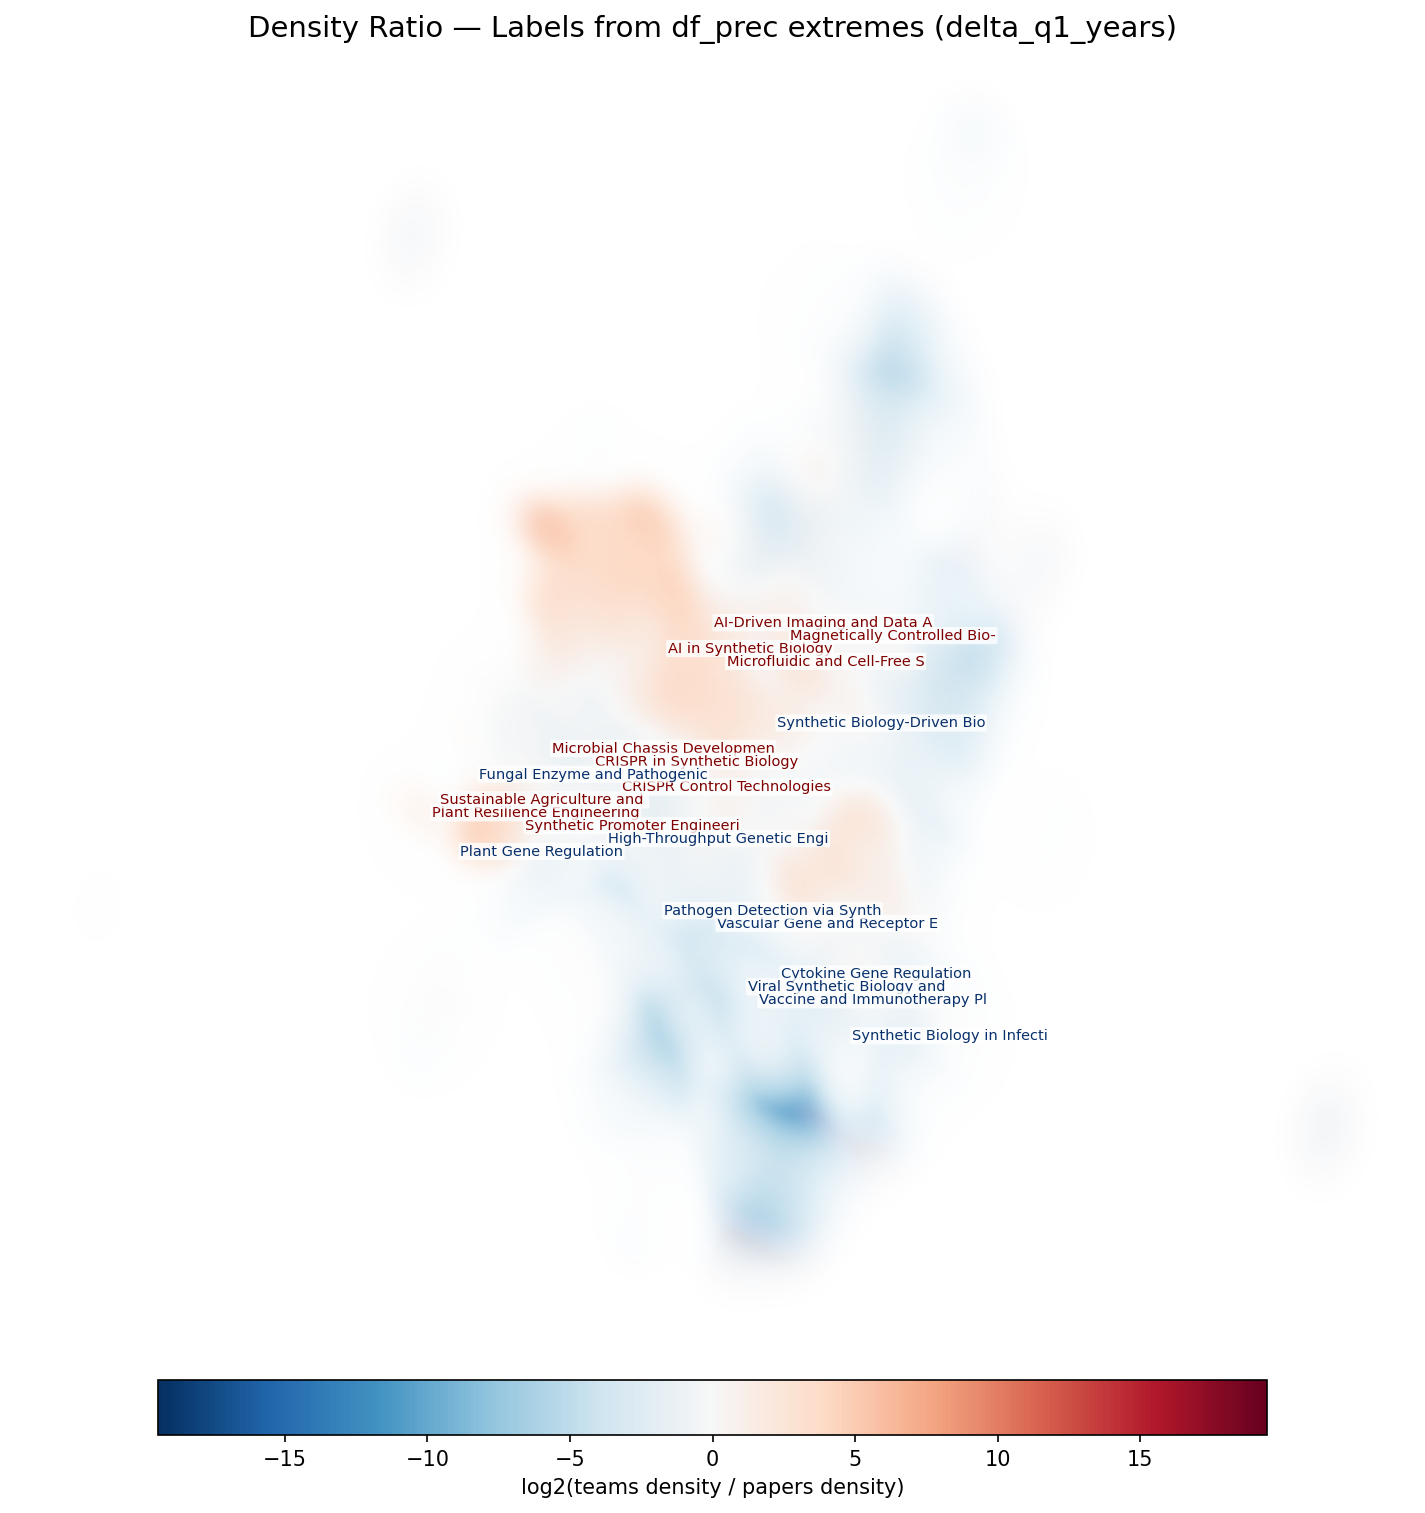

In [49]:
# --- Density ratio heatmap with df_prec extremes only (delta_q1_years, overlap-reduced labels) ---
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)

# Reuse the same density-ratio rendering style
norm = mcolors.TwoSlopeNorm(vcenter=0, vmin=-vmax, vmax=vmax)
cmap = plt.cm.RdBu_r
rgba = cmap(norm(ratio_grid))
rgba[..., 3] = alpha_grid

ax.imshow(
    rgba,
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    aspect='auto',
    interpolation='bilinear',
)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.04, pad=0.03)
cbar.set_label('log2(teams density / papers density)', fontsize=10)


def _relax_density_labels(labels_df, xlim, ylim, n_iter=280, y_min_gap_frac=0.01):
    """Force layout with extra y-axis spreading for crowded labels."""
    if labels_df.empty:
        return np.empty((0, 2), dtype=float)

    anchors = labels_df[['cx', 'cy']].to_numpy(dtype=float)
    pos = anchors.copy()

    x_span = max(xlim[1] - xlim[0], 1e-9)
    y_span = max(ylim[1] - ylim[0], 1e-9)
    y_min_gap = y_min_gap_frac * y_span

    widths = np.array([
        max(0.026, 0.0058 * len(str(lbl)) + 0.0042 * fs) * x_span / 12.0
        for lbl, fs in zip(labels_df['label'].tolist(), labels_df['fontsize'].to_numpy(dtype=float))
    ])
    heights = np.array([
        max(0.021, 0.0037 * fs) * y_span / 12.0
        for fs in labels_df['fontsize'].to_numpy(dtype=float)
    ])

    for _ in range(n_iter):
        disp = np.zeros_like(pos)
        for i in range(len(pos)):
            for j in range(i + 1, len(pos)):
                dx = pos[i, 0] - pos[j, 0]
                dy = pos[i, 1] - pos[j, 1]

                ox = 0.5 * (widths[i] + widths[j]) - abs(dx)
                oy = 0.5 * (heights[i] + heights[j]) - abs(dy)

                if ox > 0 and oy > 0:
                    sx = np.sign(dx) if abs(dx) > 1e-10 else (1 if i > j else -1)
                    sy = np.sign(dy) if abs(dy) > 1e-10 else (1 if i > j else -1)
                    disp[i, 0] += 0.06 * ox * sx
                    disp[j, 0] -= 0.06 * ox * sx
                    disp[i, 1] += 0.38 * oy * sy
                    disp[j, 1] -= 0.38 * oy * sy

        disp[:, 0] += 0.02 * (anchors[:, 0] - pos[:, 0])
        disp[:, 1] += 0.07 * (anchors[:, 1] - pos[:, 1])
        pos += disp

        order = np.argsort(pos[:, 1])
        for k in range(1, len(order)):
            prev_i = order[k - 1]
            cur_i = order[k]
            min_y = pos[prev_i, 1] + y_min_gap
            if pos[cur_i, 1] < min_y:
                pos[cur_i, 1] = min_y

        y_low = ylim[0] + 0.01 * y_span
        y_high = ylim[1] - 0.01 * y_span
        if len(order) > 0 and pos[order[-1], 1] > y_high:
            pos[:, 1] -= (pos[order[-1], 1] - y_high)
            for k in range(len(order) - 2, -1, -1):
                upper_i = order[k + 1]
                cur_i = order[k]
                max_y = pos[upper_i, 1] - y_min_gap
                if pos[cur_i, 1] > max_y:
                    pos[cur_i, 1] = max_y

        pos[:, 0] = np.clip(pos[:, 0], xlim[0] + 0.01 * x_span, xlim[1] - 0.01 * x_span)
        pos[:, 1] = np.clip(pos[:, 1], y_low, y_high)

    return pos


# Select only df_prec extremes by delta_q1_years
n_extreme = 10
if df_prec.empty:
    print('df_prec is empty: no labels to plot.')
else:
    low_ext = df_prec.sort_values('delta_q1_years', ascending=True).head(n_extreme).copy()
    high_ext = df_prec.sort_values('delta_q1_years', ascending=False).head(n_extreme).copy()

    low_ext['extreme_group'] = 'teams_preceded'
    high_ext['extreme_group'] = 'papers_preceded'

    label_df = pd.concat([low_ext, high_ext], ignore_index=True)
    label_df = label_df.drop_duplicates(subset=['topic'], keep='first')

    # Anchor labels at paper-topic centroids from the quantitative overlap section
    ctr_cols = ['topic', 'cx', 'cy', 'global_name']
    if all(c in papers_ctr.columns for c in ctr_cols):
        anchors = papers_ctr[ctr_cols].copy()
    else:
        anchors = (
            df_papers[df_papers['topic'] >= 0]
            .groupby('topic')
            .agg(
                cx=('x', 'median'),
                cy=('y', 'median'),
                global_name=('global_name', 'first'),
            )
            .reset_index()
        )

    label_df = label_df.merge(
        anchors[['topic', 'cx', 'cy', 'global_name']],
        on='topic',
        how='left',
        suffixes=('', '_anchor')
    )

    if 'global_name_anchor' in label_df.columns:
        label_df['global_name'] = label_df['global_name'].fillna(label_df['global_name_anchor'])

    # Build styled label rows and apply overlap-aware placement
    rows = []
    for _, row in label_df.iterrows():
        if pd.isna(row['cx']) or pd.isna(row['cy']):
            continue

        if row['extreme_group'] == 'teams_preceded':
            rows.append({
                'cx': row['cx'], 'cy': row['cy'], 'label': str(row['global_name'])[:28],
                'fontsize': 7.0, 'color': '#7f0000', 'box_alpha': 0.80,
            })
        else:
            rows.append({
                'cx': row['cx'], 'cy': row['cy'], 'label': str(row['global_name'])[:28],
                'fontsize': 7.0, 'color': '#08306b', 'box_alpha': 0.80,
            })

    labels_plot = pd.DataFrame(rows)
    if not labels_plot.empty:
        pos = _relax_density_labels(labels_plot, xlim=XLIM, ylim=YLIM)
        for (x, y), (_, row) in zip(pos, labels_plot.iterrows()):
            ax.text(
                x,
                y,
                row['label'],
                fontsize=float(row['fontsize']),
                ha='center',
                va='center',
                color=row['color'],
                bbox=dict(boxstyle='round,pad=0.11', fc='white', alpha=float(row['box_alpha']), ec='none'),
            )

    print(f"Labeled extremes from df_prec: {len(label_df)} topics ({n_extreme} low + {n_extreme} high, deduplicated)")

ax.set_xlim(XLIM)
ax.set_ylim(YLIM)
ax.set_title('Density Ratio — Labels from df_prec extremes (delta_q1_years)', fontsize=14)
ax.axis('off')

out_png = os.path.join(REPORTS, 'density_ratio_dfprec_extremes.png')
fig.savefig(out_png, dpi=220, bbox_inches='tight')
print(f"Saved -> {out_png}")
plt.show()

Topics in df_prec: 70
Topics plotted: 70


/var/folders/l3/ykgptl812qndpwdm6n3tm9jr0000gn/T/ipykernel_15173/3618491505.py:59: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/l3/ykgptl812qndpwdm6n3tm9jr0000gn/T/ipykernel_15173/3618491505.py:59: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.25`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


Saved -> ../assets/reports/overlap_precedence_violin_horizontal.png


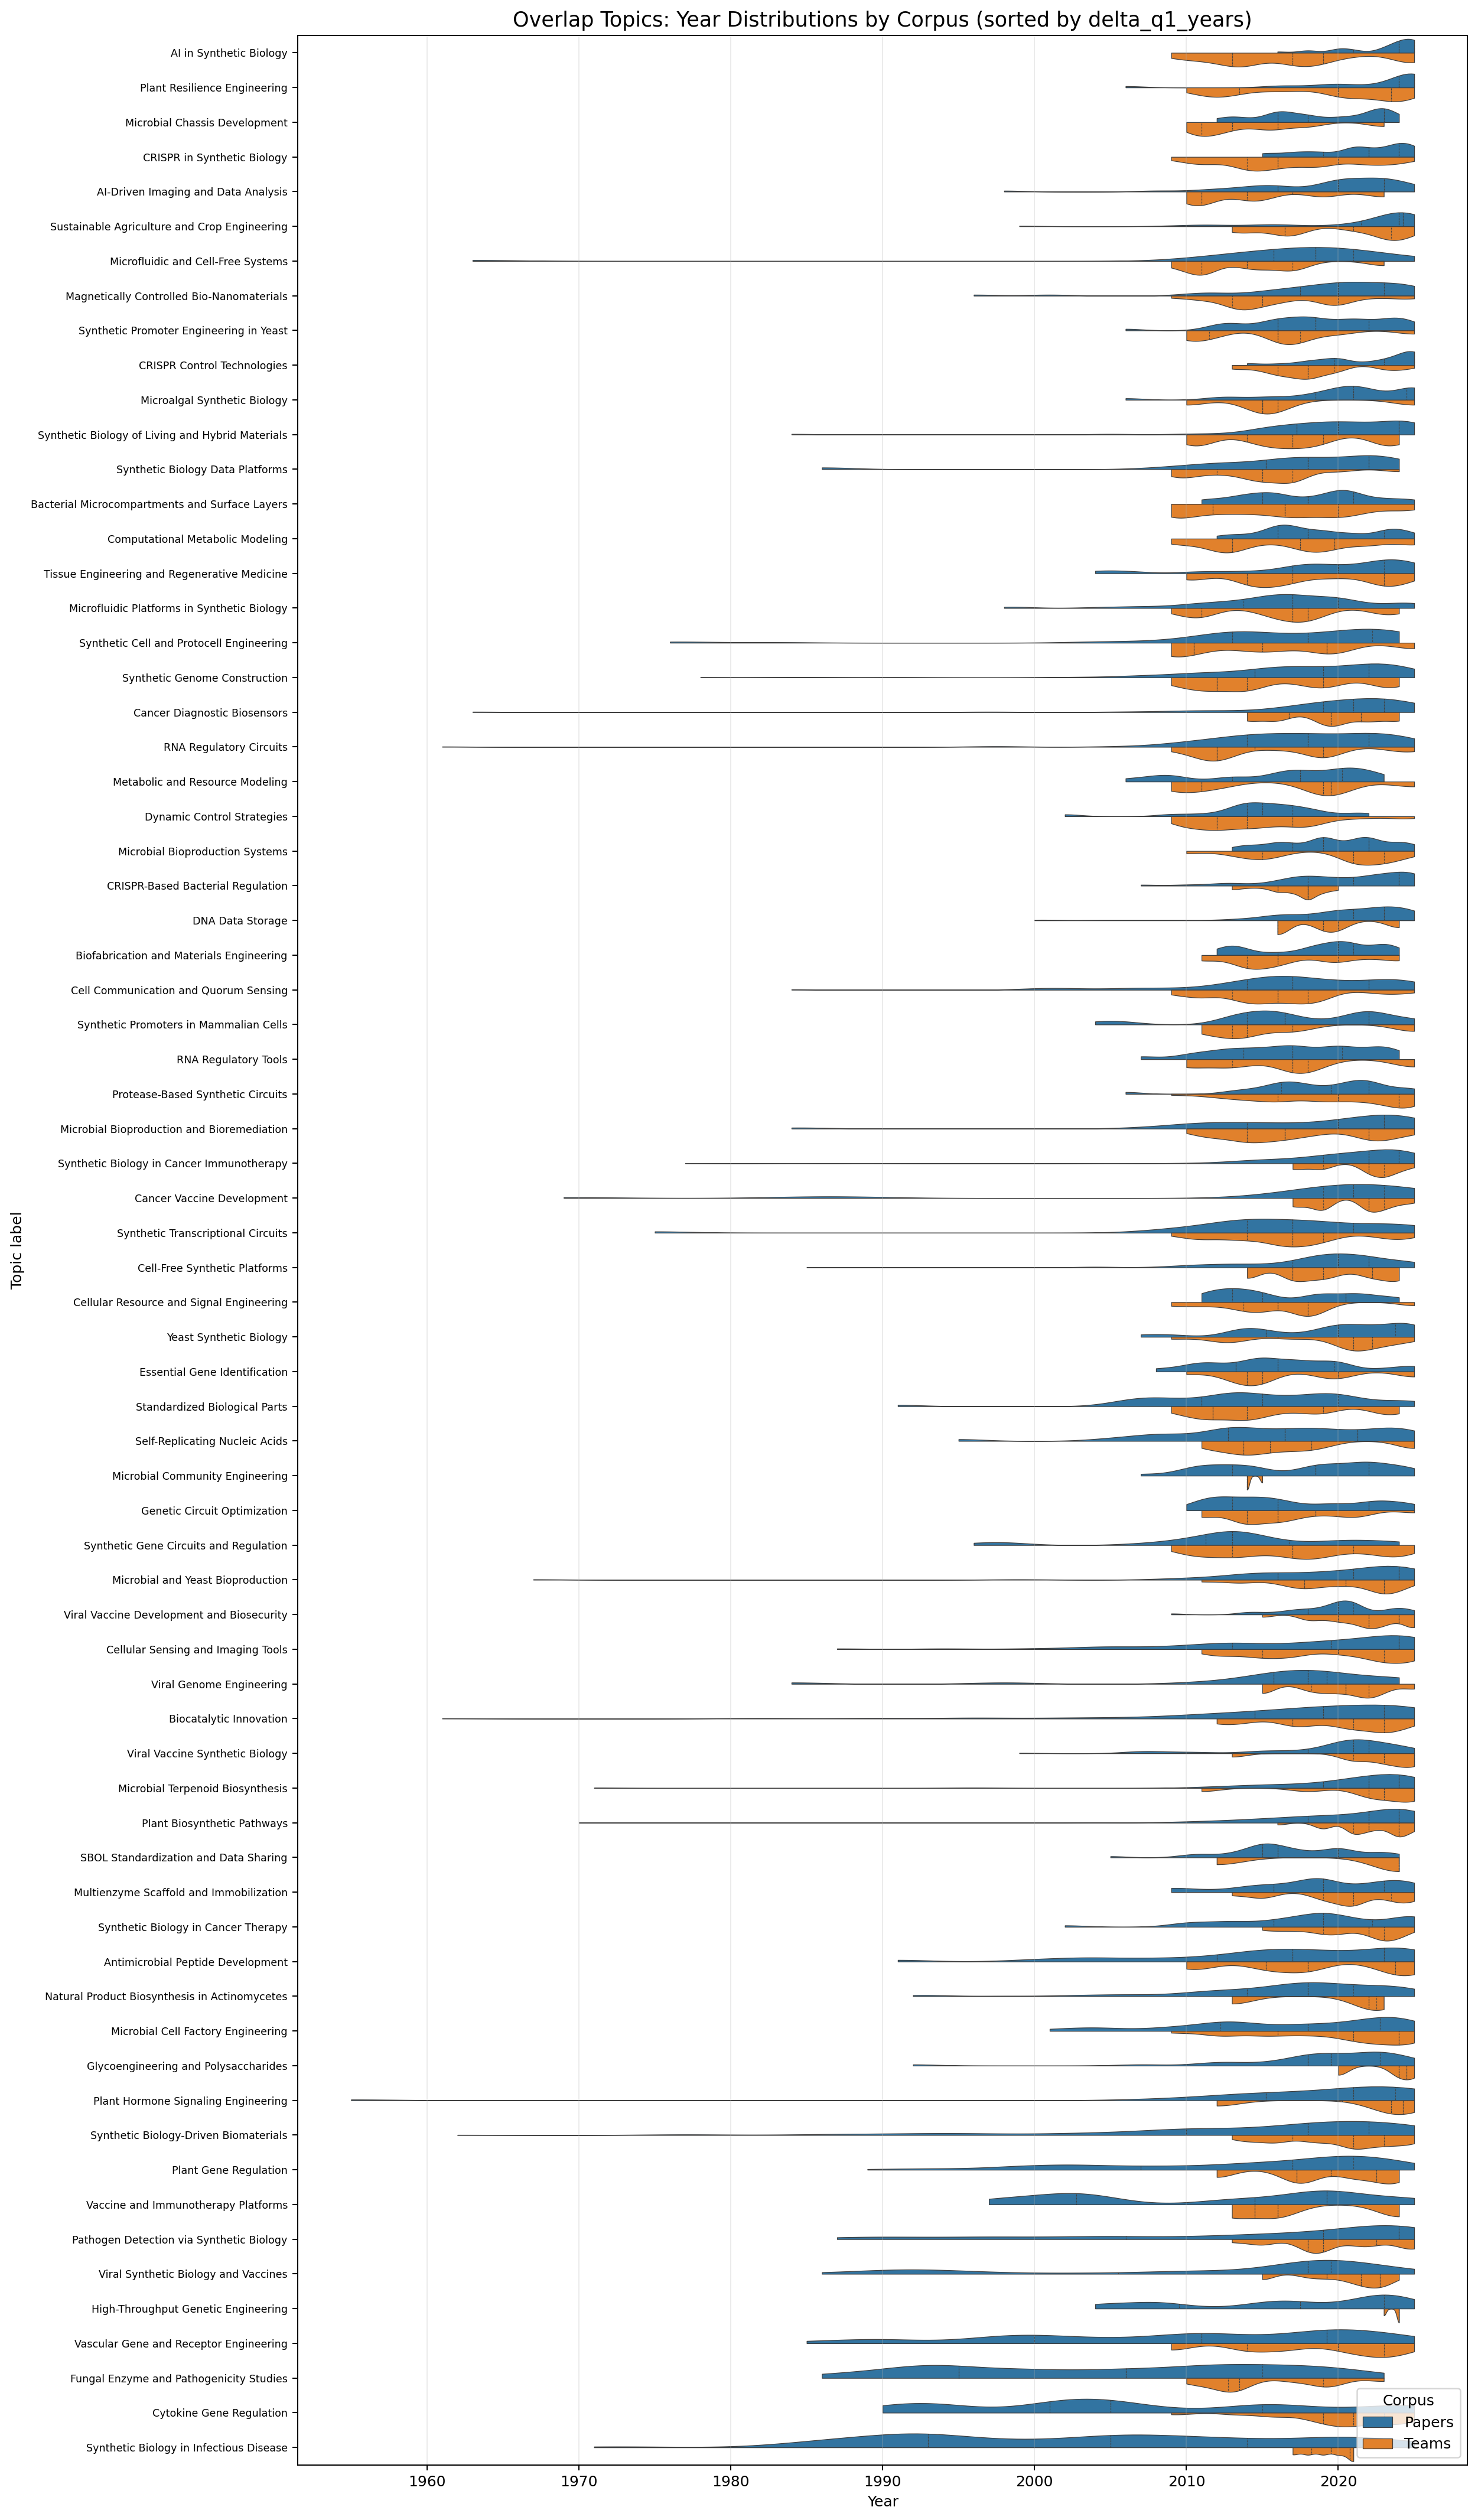

In [13]:
# --- Option A: Horizontal split-violin by overlap topic (sorted by delta_q1_years) ---
import seaborn as sns
from scipy.spatial import cKDTree

# 1) Topic order from df_prec
plot_topics = df_prec.sort_values('delta_q1_years', ascending=True).copy()
plot_topics['topic_label'] = plot_topics['global_name'].astype(str).str.slice(0, 60)

# 2) Rebuild paper and team year pools at document/project level
_df_p_plot = df_papers[df_papers['topic'] >= 0][['topic', 'x', 'y', 'id']].merge(
    papers[['id', 'publication_year']], on='id', how='left'
)
_df_p_plot['publication_year'] = pd.to_numeric(_df_p_plot['publication_year'], errors='coerce')

teams_years = pd.read_csv(os.path.join(ASSETS, 'igem.txt'), sep='\t', usecols=['UT', 'Year_y'])
teams_years['Year_y'] = pd.to_numeric(teams_years['Year_y'], errors='coerce')
_df_t_plot = df_teams[['UT', 'x', 'y']].merge(teams_years, on='UT', how='left')

teams_tree_plot = cKDTree(_df_t_plot[['x', 'y']].to_numpy())

# 3) Build long-form data for split violins
records = []
for _, row in plot_topics.iterrows():
    topic_id = row['topic']
    topic_label = row['topic_label']

    psub = _df_p_plot[_df_p_plot['topic'] == topic_id]
    pyears = psub['publication_year'].dropna()
    if psub.empty or pyears.empty:
        continue

    cx = psub['x'].median()
    cy = psub['y'].median()
    dists = np.sqrt((psub['x'].values - cx) ** 2 + (psub['y'].values - cy) ** 2)
    radius = np.median(dists) * 1.5

    nearby_idx = teams_tree_plot.query_ball_point([cx, cy], r=radius)
    tyears = _df_t_plot.iloc[nearby_idx]['Year_y'].dropna()

    # Keep same evidence rule as precedence code
    if len(tyears) < 3:
        continue

    records.extend([{'topic_label': topic_label, 'year': float(y), 'corpus': 'Papers'} for y in pyears.values])
    records.extend([{'topic_label': topic_label, 'year': float(y), 'corpus': 'Teams'} for y in tyears.values])

plot_df = pd.DataFrame(records)

ordered_labels = plot_topics['topic_label'].tolist()
plot_df = plot_df[plot_df['topic_label'].isin(ordered_labels)].copy()
plot_df['topic_label'] = pd.Categorical(plot_df['topic_label'], categories=ordered_labels, ordered=True)

print(f"Topics in df_prec: {len(plot_topics)}")
print(f"Topics plotted: {plot_df['topic_label'].nunique()}")

# 4) Plot
fig_h = max(18, 0.34 * len(ordered_labels))
fig, ax = plt.subplots(figsize=(14, fig_h), dpi=180)
sns.violinplot(
    data=plot_df,
    y='topic_label',
    x='year',
    hue='corpus',
    split=True,
    orient='h',
    inner='quart',
    cut=0,
    bw=0.25,
    scale='width',
    linewidth=0.5,
    palette={'Papers': '#1f77b4', 'Teams': '#ff7f0e'},
    ax=ax,
 )

ax.set_title('Overlap Topics: Year Distributions by Corpus (sorted by delta_q1_years)', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Topic label')
ax.tick_params(axis='y', labelsize=7)
ax.grid(axis='x', alpha=0.25)
ax.legend(title='Corpus', loc='lower right')
plt.tight_layout()

out_png = os.path.join(REPORTS, 'overlap_precedence_violin_horizontal.png')
fig.savefig(out_png, dpi=220, bbox_inches='tight')
print(f"Saved -> {out_png}")
plt.show()

Saved -> ../assets/reports/overlap_precedence_dumbbell_horizontal.png


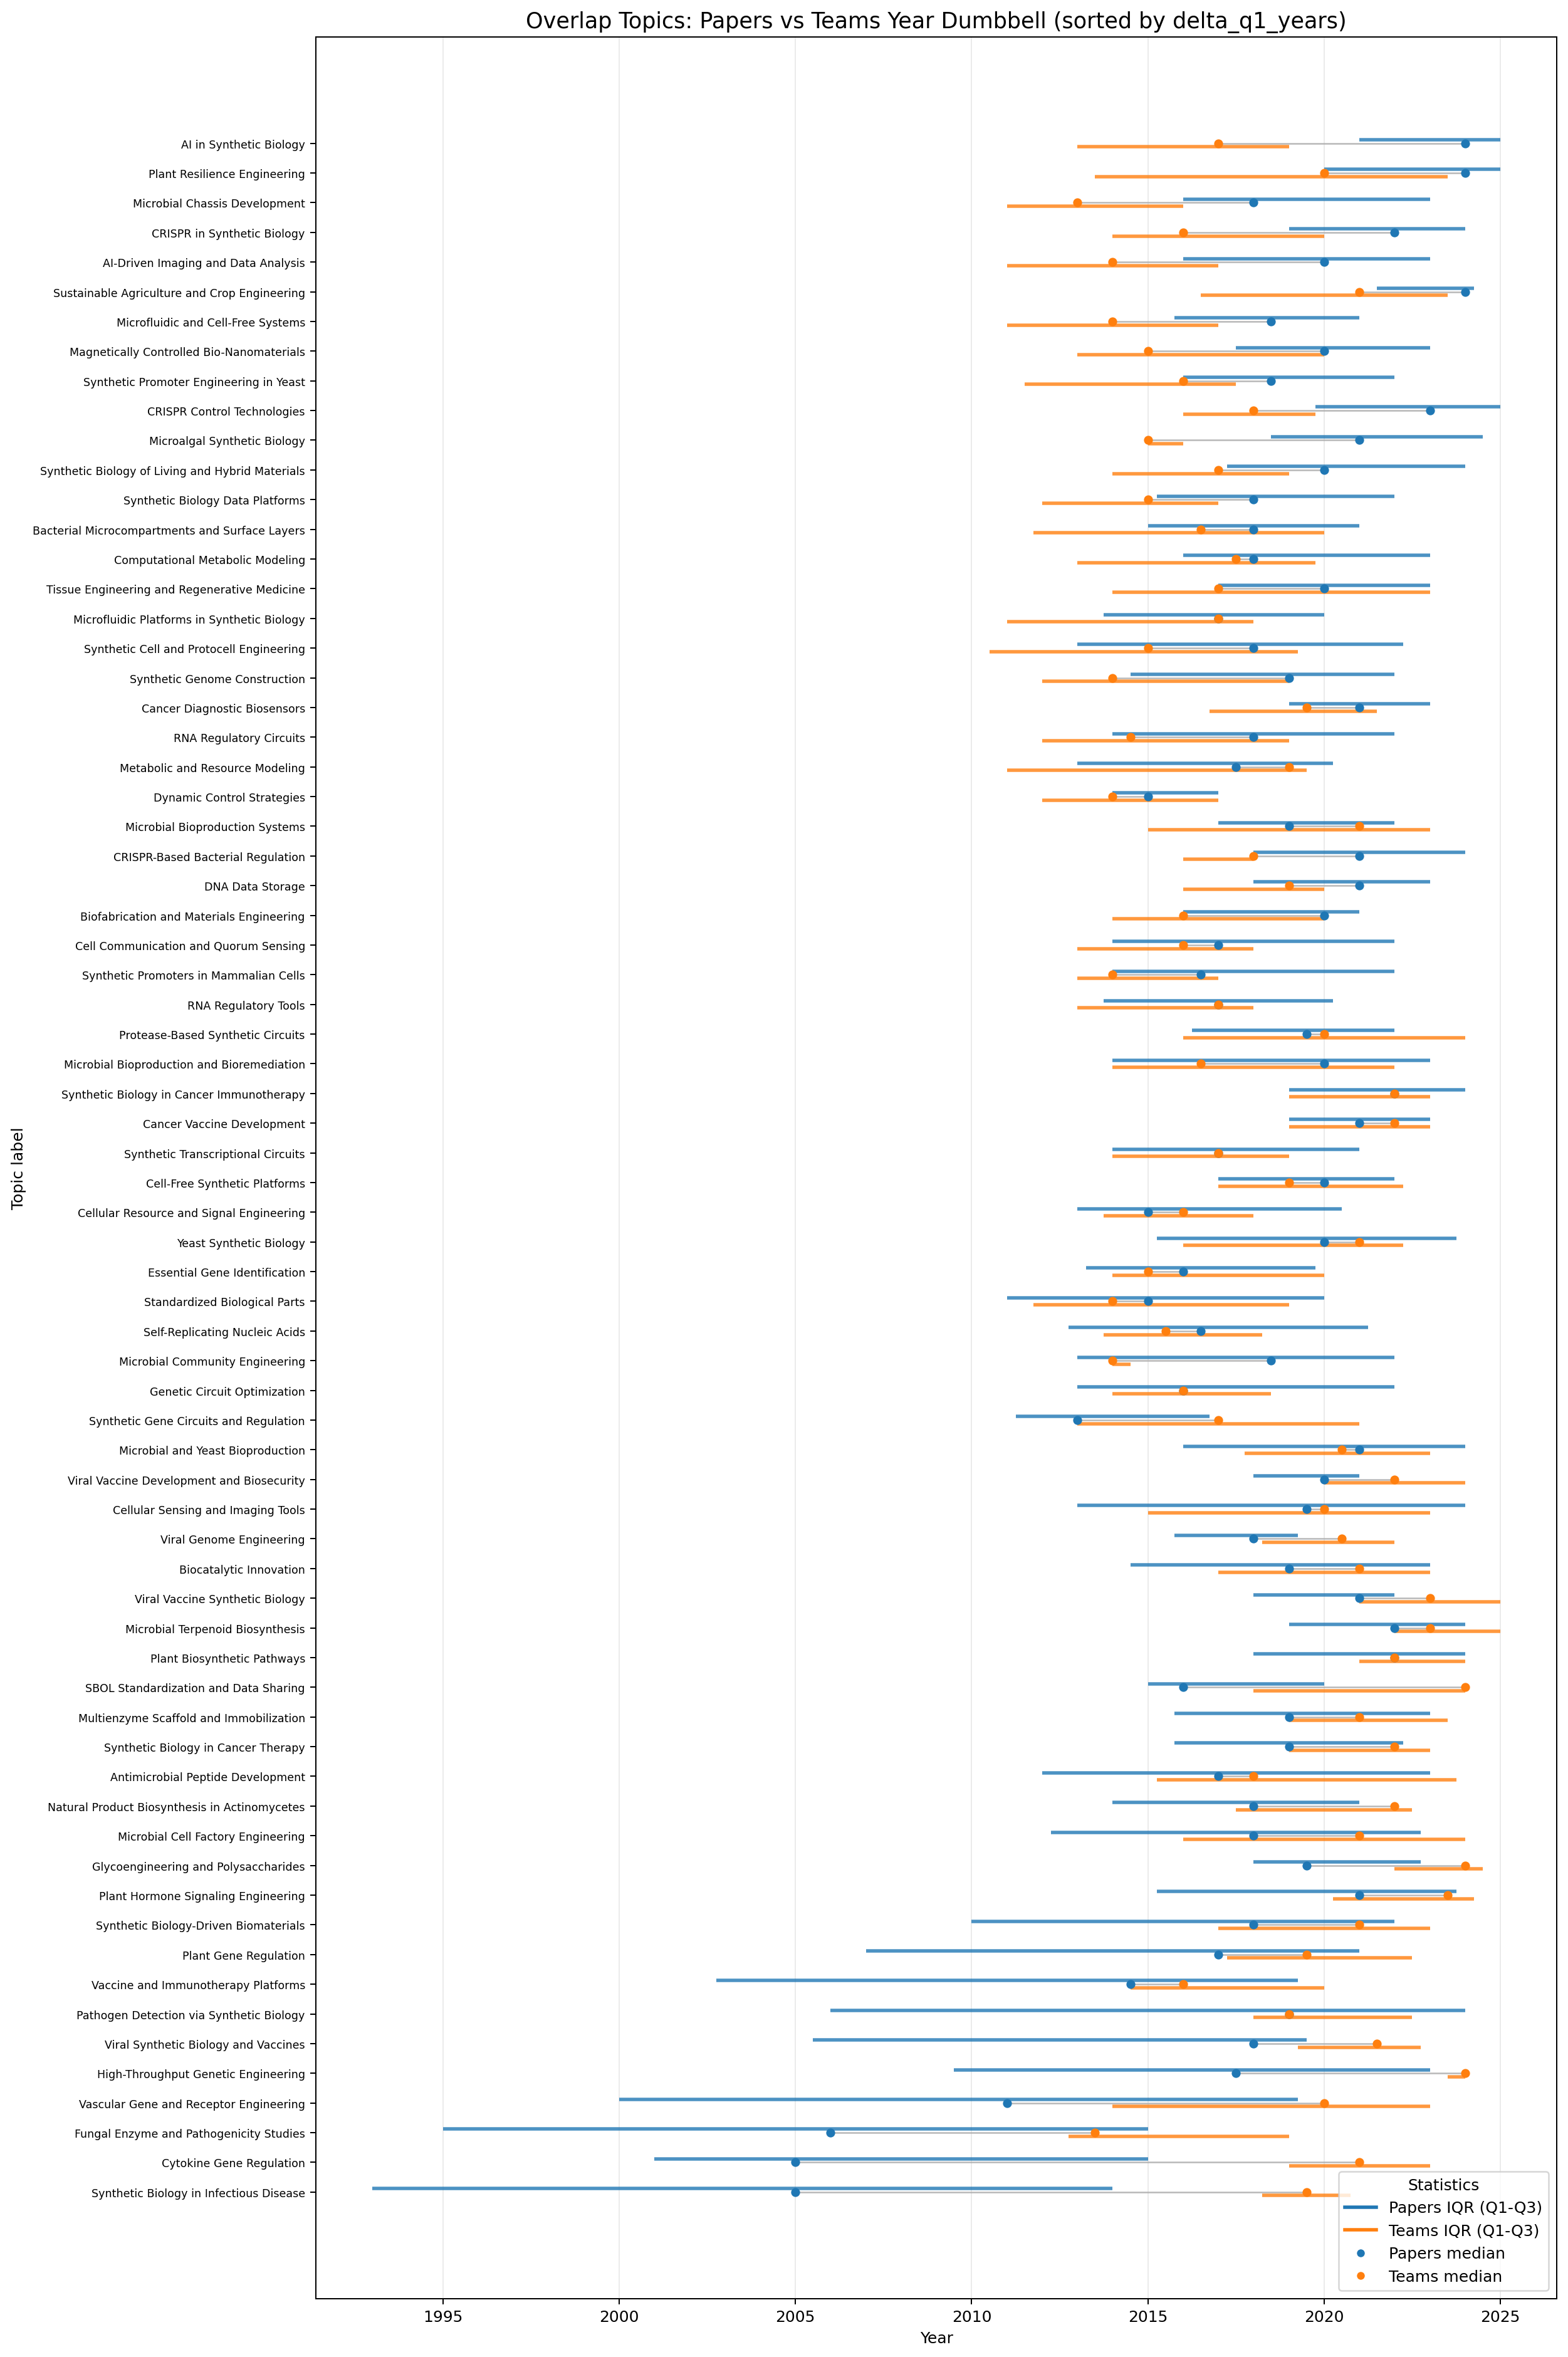

In [14]:
# --- Option B: Horizontal dumbbell chart (papers vs teams medians, sorted by delta_q1_years) ---
# Uses summary stats already present in df_prec
db = df_prec.sort_values('delta_q1_years', ascending=True).copy() #teams_q1_year #delta_q1_years
db['topic_label'] = db['global_name'].astype(str).str.slice(0, 60)

y = np.arange(len(db))

fig_h = max(14, 0.30 * len(db))
fig, ax = plt.subplots(figsize=(14, fig_h), dpi=180)

# Connecting lines: papers median -> teams median
ax.hlines(
    y=y,
    xmin=db['papers_median_year'],
    xmax=db['teams_median_year'],
    color='0.65',
    linewidth=1.0,
    alpha=0.8,
    zorder=1,
 )

# IQR bands as short horizontal segments for context
ax.hlines(y - 0.12, db['papers_q1_year'], db['papers_q3_year'], color='#1f77b4', linewidth=2.2, alpha=0.8, zorder=2)
ax.hlines(y + 0.12, db['teams_q1_year'], db['teams_q3_year'], color='#ff7f0e', linewidth=2.2, alpha=0.8, zorder=2)

# Median markers
ax.scatter(db['papers_median_year'], y, s=22, color='#1f77b4', label='Papers median', zorder=3)
ax.scatter(db['teams_median_year'], y, s=22, color='#ff7f0e', label='Teams median', zorder=3)

ax.set_yticks(y)
ax.set_yticklabels(db['topic_label'], fontsize=7)
ax.invert_yaxis()  # smallest delta_q1_years at top
ax.set_xlabel('Year')
ax.set_ylabel('Topic label')
ax.set_title('Overlap Topics: Papers vs Teams Year Dumbbell (sorted by delta_q1_years)', fontsize=14)
ax.grid(axis='x', alpha=0.25)

# Small legend for IQR segments
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], color='#1f77b4', lw=2.2, label='Papers IQR (Q1-Q3)'),
    Line2D([0], [0], color='#ff7f0e', lw=2.2, label='Teams IQR (Q1-Q3)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#1f77b4', markersize=6, label='Papers median'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff7f0e', markersize=6, label='Teams median'),
]
ax.legend(handles=legend_items, loc='lower right', title='Statistics')

plt.tight_layout()

out_png = os.path.join(REPORTS, 'overlap_precedence_dumbbell_horizontal.png')
fig.savefig(out_png, dpi=220, bbox_inches='tight')
print(f"Saved -> {out_png}")
plt.show()

Saved -> ../assets/reports/overlap_precedence_diverging_gap.png


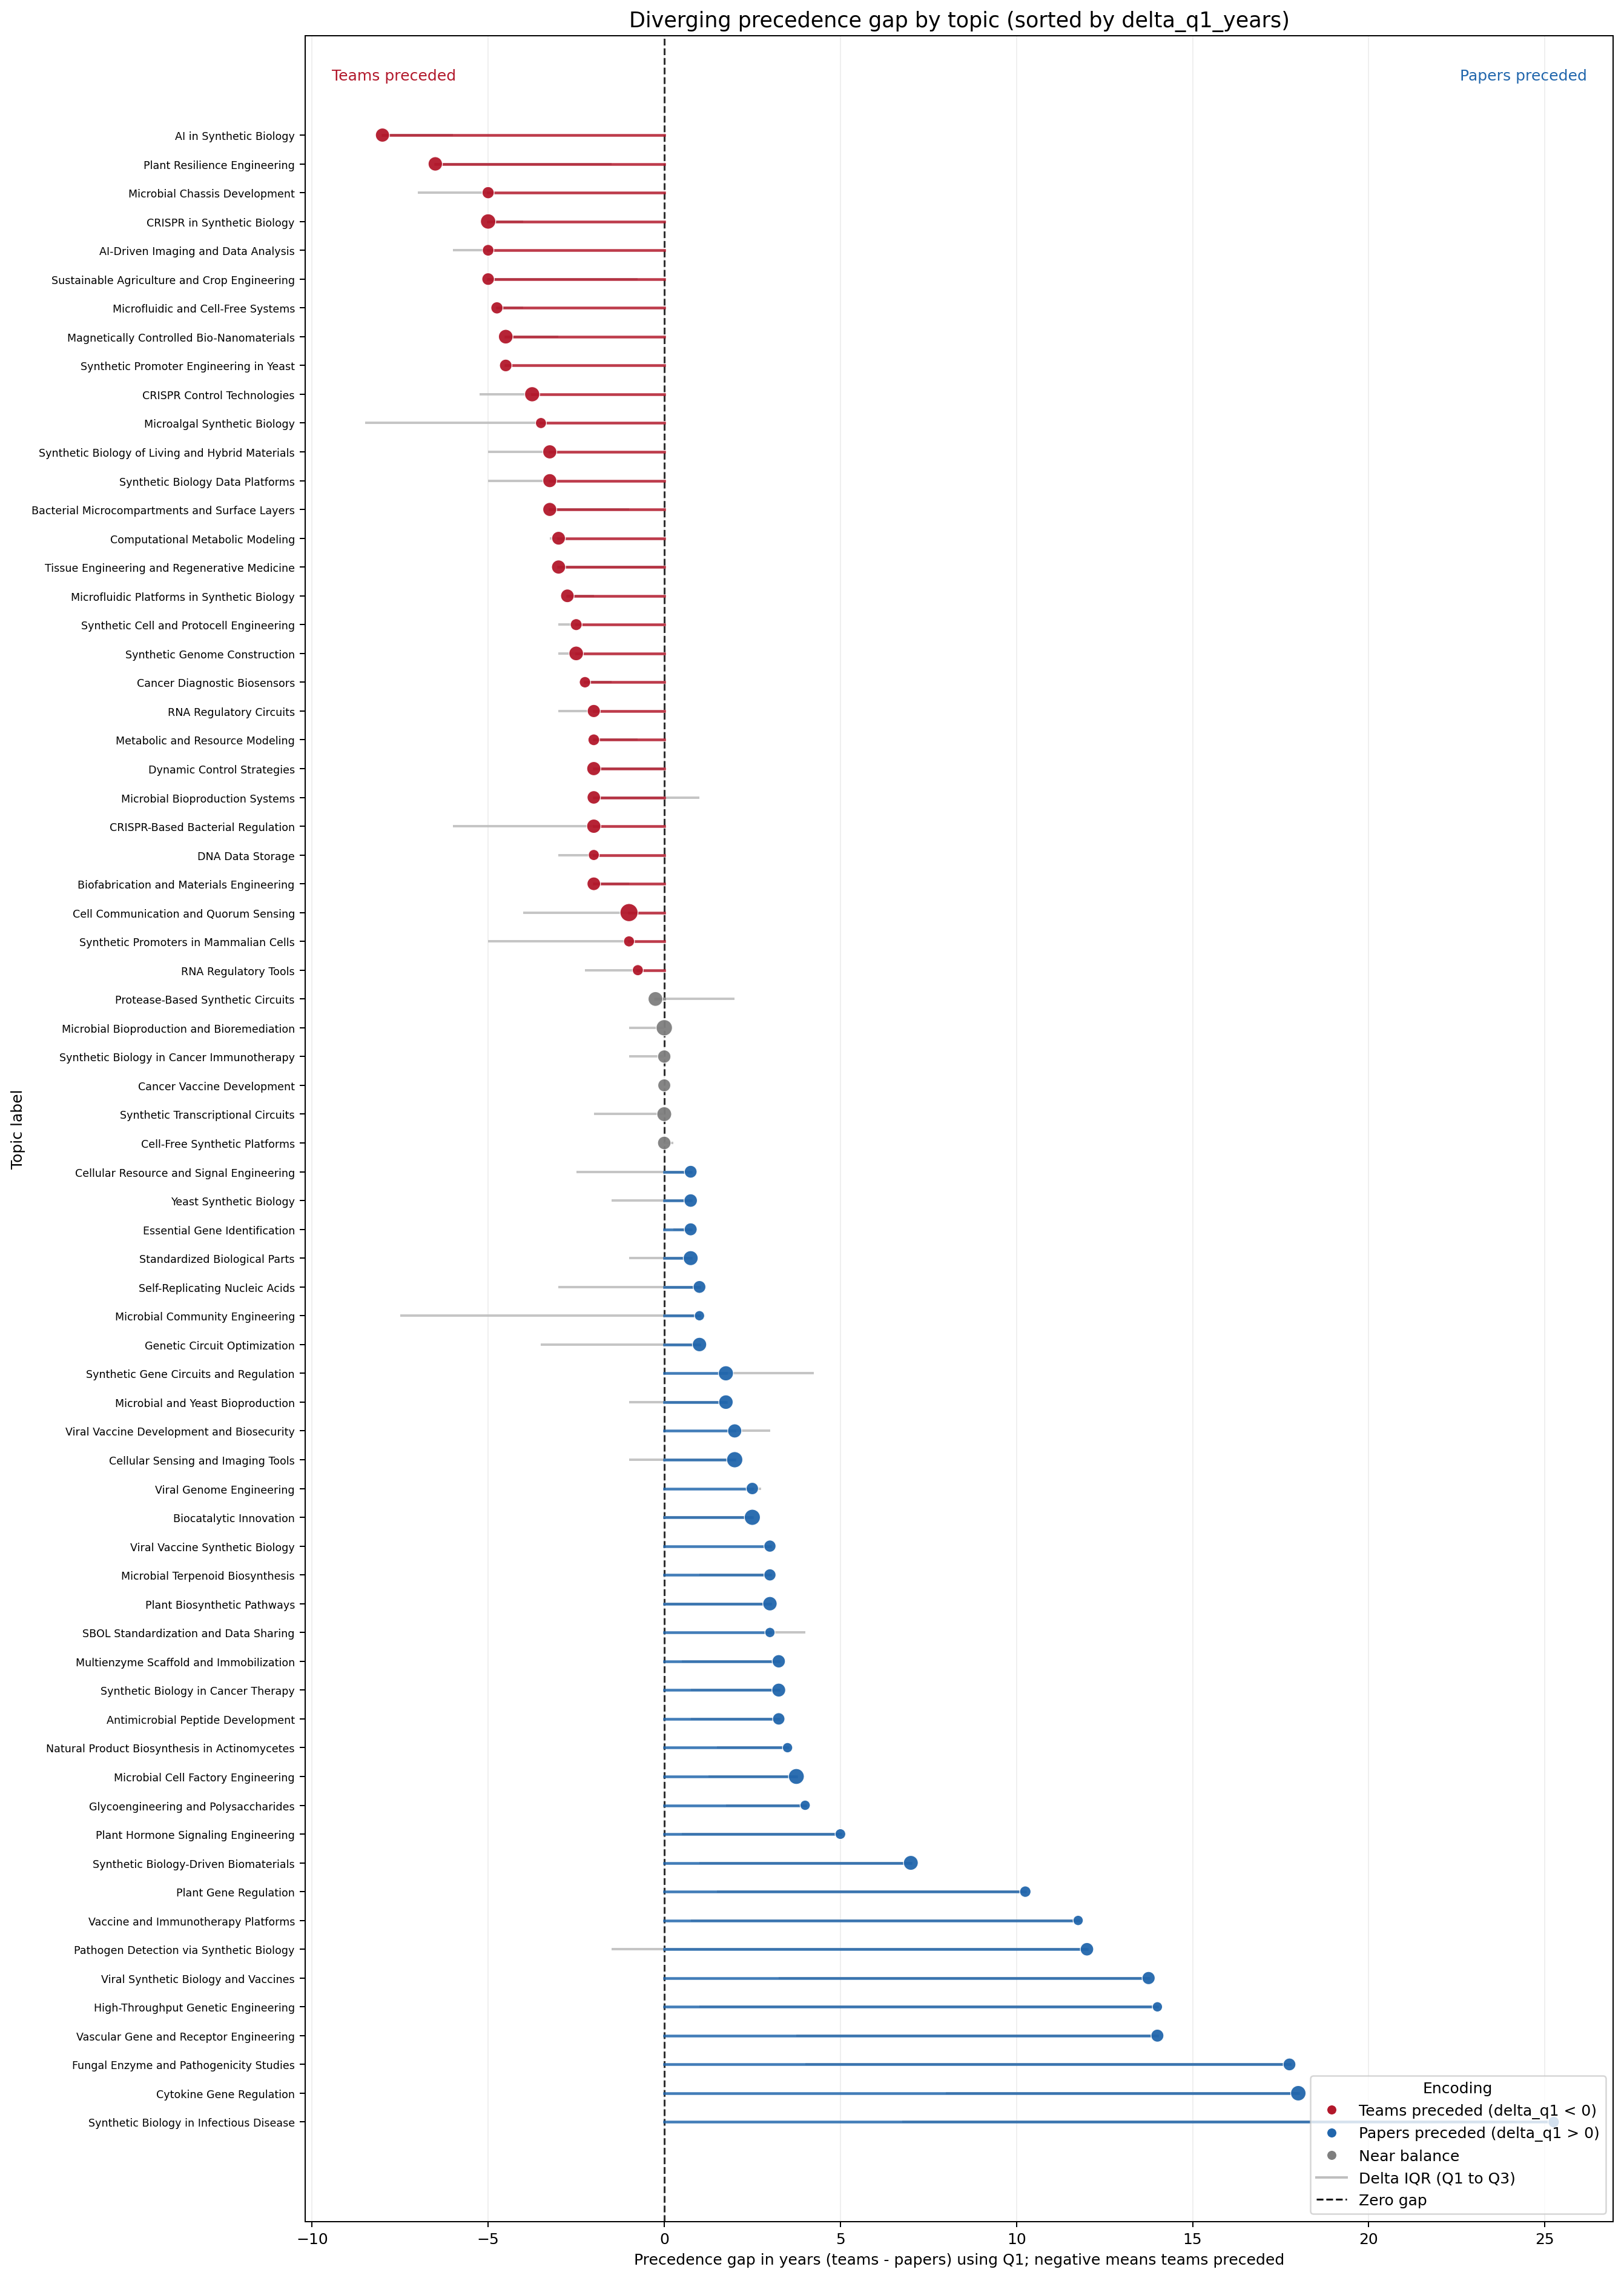

In [15]:
# --- Option C: Diverging precedence gap plot (centered at zero) ---
# Highlights which topics are teams-first (negative) vs papers-first (positive)
dg = df_prec.sort_values('delta_q1_years', ascending=True).copy()
dg['topic_label'] = dg['global_name'].astype(str).str.slice(0, 60)

# Evidence strength for marker size: conservative overlap support
dg['support'] = np.minimum(dg['n_papers'], dg['n_nearby_teams'])
sup = dg['support'].fillna(0)
if sup.max() > 0:
    dg['marker_size'] = 20 + 120 * np.sqrt(sup / sup.max())
else:
    dg['marker_size'] = 30

# Color by precedence direction using delta_q1_years
def _gap_color(v):
    if v < -0.25:
        return '#b2182b'  # teams preceded (left side)
    if v > 0.25:
        return '#2166ac'  # papers preceded (right side)
    return '#7f7f7f'      # near-balanced

dg['gap_color'] = dg['delta_q1_years'].apply(_gap_color)
y = np.arange(len(dg))

fig_h = max(14, 0.30 * len(dg))
fig, ax = plt.subplots(figsize=(15, fig_h), dpi=180)

# Reference lines
ax.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.9, zorder=1)
ax.grid(axis='x', alpha=0.20, zorder=0)

# Uncertainty segment in delta space: Q1 to Q3 around median (all as teams minus papers)
ax.hlines(
    y=y,
    xmin=dg['delta_q1_years'],
    xmax=dg['delta_q3_years'],
    color='0.75',
    linewidth=1.6,
    alpha=0.9,
    zorder=2,
 )

# Lollipop stems from 0 to delta_q1_years
for yi, val, col in zip(y, dg['delta_q1_years'], dg['gap_color']):
    ax.plot([0, val], [yi, yi], color=col, linewidth=1.8, alpha=0.85, zorder=3)

# Main markers at delta_q1_years
ax.scatter(
    dg['delta_q1_years'],
    y,
    s=dg['marker_size'],
    c=dg['gap_color'],
    edgecolor='white',
    linewidth=0.5,
    alpha=0.95,
    zorder=4,
 )

ax.set_yticks(y)
ax.set_yticklabels(dg['topic_label'], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('Precedence gap in years (teams - papers) using Q1; negative means teams preceded')
ax.set_ylabel('Topic label')
ax.set_title('Diverging precedence gap by topic (sorted by delta_q1_years)', fontsize=14)

# Side annotations for quick reading
xmin, xmax = ax.get_xlim()
span = xmax - xmin
ax.text(xmin + 0.02 * span, -1.8, 'Teams preceded', color='#b2182b', fontsize=10, ha='left', va='bottom')
ax.text(xmax - 0.02 * span, -1.8, 'Papers preceded', color='#2166ac', fontsize=10, ha='right', va='bottom')

# Legend
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#b2182b', markersize=7, label='Teams preceded (delta_q1 < 0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2166ac', markersize=7, label='Papers preceded (delta_q1 > 0)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#7f7f7f', markersize=7, label='Near balance'),
    Line2D([0], [0], color='0.75', lw=1.6, label='Delta IQR (Q1 to Q3)'),
    Line2D([0], [0], color='black', lw=1.2, linestyle='--', label='Zero gap'),
]
ax.legend(handles=legend_items, loc='lower right', title='Encoding')

plt.tight_layout()

out_png = os.path.join(REPORTS, 'overlap_precedence_diverging_gap.png')
fig.savefig(out_png, dpi=220, bbox_inches='tight')
print(f"Saved -> {out_png}")
plt.show()